
# EEG 7-Class Signal Quality Before/After Preprocessing, ERD/ERS and Classification

This notebook is tailored to the seven recorded classes:

1. **Clenching Left Hand**
2. **Clenching Right Hand**
3. **Moving Left Leg**
4. **Moving Right Leg**
5. **Moving Tongue**
6. **Eye Open**
7. **Eye Close**

It builds four EEG classifiers:

- **Task A — all 7 classes**
- **Task B — left hand vs right hand**
- **Task C — left leg vs right leg**
- **Task D — tongue vs eye close vs eye open**

The analysis uses **2-second EEG windows**. By default, windows move every 1 second, but all windows from the same labeled movement span are kept in the same cross-validation fold so overlapping windows cannot leak into both training and testing.

### What is added in this revision

This version calculates the **same signal-quality metrics twice**:

1. **RAW QC** — before notch filtering, band-pass filtering, or CAR.
2. **PROCESSED QC** — after the complete preprocessing pipeline.

It then creates a **before-vs-after comparison table** for every channel and session so that preprocessing effects can be quantified rather than inferred only from plots.

The notebook includes:

- recording inventory and label checks;
- raw signal-quality analysis **before preprocessing**;
- post-processing signal-quality analysis **after preprocessing**;
- channel-wise **before/after QC comparison**;
- **motor-imagery-style ±100 µV epoch screening** after filtering, reported overall/by class/by session/by channel;
- robust PTP, RMS, SD, mean/median absolute peak amplitude, flatness, extreme-amplitude fraction, line noise, drift, high-frequency contamination, spectral slope, and SNR proxy;
- 60 Hz notch filtering;
- zero-phase 1–45 Hz band-pass filtering;
- optional common-average reference;
- artifact detection and contaminated-window rejection;
- raw-vs-processed time-series and PSD plots;
- delta, theta, alpha/mu, beta and gamma power;
- time-domain, Hjorth, entropy and spectral features;
- cue-locked and condition-reference **ERD/ERS**;
- leakage-aware classification;
- CSP + LDA for left-vs-right hand and left-vs-right leg;
- confusion matrices, balanced accuracy, macro-F1 and per-class reports;
- permutation-label sanity checks;
- final model export.

> **Important scientific point:** physical hand, leg, and especially tongue movement can generate EMG/movement artifacts that are easier to classify than cortical EEG. High classification accuracy alone therefore does not prove that the model learned cortical activity. Raw QC, processed QC, artifact screening, ERD/ERS, and artifact-sensitivity analysis should be interpreted together.



## 0. Installation and configuration

The notebook first tries your project's `neurobridge.io.recording.load_recording`, because that loader knows how your saved `.npz` recordings and annotations are structured. A generic NPZ fallback is included.

Core packages:

```bash
pip install numpy pandas scipy matplotlib scikit-learn joblib
```

**ICA is not used in this notebook.** Artifact handling is performed through acquisition-level QC, filtering/referencing, and contaminated-window rejection.


In [1]:

from __future__ import annotations

import json
import math
import os
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal, stats
from scipy.linalg import eigh

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42

# ---------------------------- DATA ---------------------------------
# The recordings live in Session_Classification/ at the top of this repository:
# Session_Classification/
#   PT-003/
#       PT-003_session01_....npz
#       PT-003_session02_....npz
# The folder is found by searching upward from the folder the notebook runs in,
# so no path needs editing. To analyse recordings stored somewhere else, replace
# the call below with an explicit path, e.g.
#   SESSIONS_ROOT = Path(r"D:\eeg\Session_Classification")
def find_sessions_root(name="Session_Classification"):
    here = Path.cwd().resolve()
    for folder in (here, *here.parents):
        if (folder / name).is_dir():
            try:
                return Path(os.path.relpath(folder / name))
            except ValueError:  # on another drive (Windows)
                return folder / name
    raise FileNotFoundError(
        f"No '{name}' folder in {here} or any folder above it. Start Jupyter "
        "inside the repository, or set SESSIONS_ROOT to an explicit path."
    )


SESSIONS_ROOT = find_sessions_root()
print("Sessions root:", SESSIONS_ROOT)

# If you only want one participant, enter e.g. "PT-003".
# Set to None to recursively analyze every participant folder.
PARTICIPANT = "PT-003"

# ------------------------ EEG SETTINGS ------------------------------
SF_EXPECTED = 250.0      # Unicorn is normally 250 Hz; actual file metadata wins.
MAINS_HZ = 60.0          # North America. Use 50.0 in 50-Hz regions.
L_FREQ = 1.0
H_FREQ = 45.0
APPLY_CAR = True         # common-average reference after filtering

# ----------------------- WINDOW SETTINGS ----------------------------
WINDOW_SECONDS = 2.0     # requested window size
STEP_SECONDS = 1.0       # 50% overlap; leakage is prevented by span-group CV
START_OFFSET_SECONDS = 0.0

# ---------------------- ARTIFACT SETTINGS ---------------------------
# Conservative screening thresholds. Inspect distributions before changing.
# EXTREME_ABS_UV is used only as a descriptive whole-recording QC metric;
# it is NOT a hardware amplifier-saturation limit.
EXTREME_ABS_UV = 500.0
MAX_ABS_UV = 200.0
MAX_PTP_UV = 300.0
MAX_STEP_UV = 100.0
FLAT_STD_UV = 0.2
MAX_BAD_CHANNEL_FRACTION = 0.25

# ---------------- MOTOR-IMAGERY COMPARISON QC --------------------
# Literature-comparable amplitude screening criterion applied to each
# FILTERED 2-second epoch. This is reported separately from the notebook's
# own artifact-rejection rule and does NOT automatically reject an epoch.
MI_ABS_THRESHOLD_UV = 100.0


BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha_mu": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 45.0),
}

CLASS_ORDER = [
    "Clenching Left Hand",
    "Clenching Right Hand",
    "Moving Left Leg",
    "Moving Right Leg",
    "Moving Tongue",
    "Eye Open",
    "Eye Close",
]

TASKS = {
    "all_7": CLASS_ORDER,
    "hand_L_vs_R": ["Clenching Left Hand", "Clenching Right Hand"],
    "leg_L_vs_R": ["Moving Left Leg", "Moving Right Leg"],
    "tongue_vs_eye_states": ["Moving Tongue", "Eye Close", "Eye Open"],
}

CENTRAL_CHANNELS = ["C3", "Cz", "C4"]
MODEL_DIR = SESSIONS_ROOT / "_models_7class_2s"
RESULTS_DIR = SESSIONS_ROOT / "_analysis_7class_2s"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 200)

print("Window:", WINDOW_SECONDS, "s | step:", STEP_SECONDS, "s")
print("Filter:", L_FREQ, "-", H_FREQ, "Hz | mains:", MAINS_HZ, "Hz | CAR:", APPLY_CAR)
print("MI comparison threshold: |EEG| >", MI_ABS_THRESHOLD_UV, "µV per filtered 2-s epoch")


Sessions root: ..\Session_Classification
Window: 2.0 s | step: 1.0 s
Filter: 1.0 - 45.0 Hz | mains: 60.0 Hz | CAR: True
MI comparison threshold: |EEG| > 100.0 µV per filtered 2-s epoch



## 1. Label harmonization

This keeps small spelling differences from silently creating extra classes. The canonical labels remain exactly the seven labels shown above.


In [2]:

LABEL_ALIASES = {
    "clenching left hand": "Clenching Left Hand",
    "clench left hand": "Clenching Left Hand",
    "left hand": "Clenching Left Hand",

    "clenching right hand": "Clenching Right Hand",
    "clench right hand": "Clenching Right Hand",
    "right hand": "Clenching Right Hand",

    "moving left leg": "Moving Left Leg",
    "left leg": "Moving Left Leg",
    "move left leg": "Moving Left Leg",

    "moving right leg": "Moving Right Leg",
    "right leg": "Moving Right Leg",
    "move right leg": "Moving Right Leg",

    "moving tongue": "Moving Tongue",
    "tongue": "Moving Tongue",
    "move tongue": "Moving Tongue",

    "eye open": "Eye Open",
    "eyes open": "Eye Open",

    "eye close": "Eye Close",
    "eye closed": "Eye Close",
    "eyes closed": "Eye Close",
}

def canonical_label(x):
    if x is None:
        return None
    s = str(x).strip()
    if s in CLASS_ORDER:
        return s
    return LABEL_ALIASES.get(s.lower(), s)



## 2. Recording loader

Preferred path: the notebook imports `neurobridge.io.recording.load_recording`.

The generic fallback supports an NPZ containing `data`, `eeg`, or `samples`, plus metadata such as sampling frequency, channel names and annotations. If the fallback cannot find annotations, use your Neurobridge environment so the project loader can recover the exact marker spans.


In [3]:

@dataclass
class EEGRecording:
    data_uv: np.ndarray
    sf: float
    names: list[str]
    annotations: list[dict]
    participant: str
    session: str
    source: str
    filtered_uv: np.ndarray | None = None
    qc: pd.DataFrame | None = None
    notes: list[str] = field(default_factory=list)

    def validate(self):
        x = np.asarray(self.data_uv, dtype=float)
        if x.ndim != 2:
            raise ValueError(f"EEG must be 2-D, got {x.shape}")
        if x.shape[0] != len(self.names) and x.shape[1] == len(self.names):
            x = x.T
        if x.shape[0] != len(self.names):
            raise ValueError(
                f"{self.source}: {x.shape[0]} data rows but {len(self.names)} channel names"
            )
        if self.sf <= 0:
            raise ValueError("Sampling frequency must be positive")
        self.data_uv = x
        return self


def _decode_meta(value):
    if isinstance(value, np.ndarray) and value.shape == ():
        value = value.item()
    if isinstance(value, bytes):
        value = value.decode("utf-8")
    if isinstance(value, str):
        try:
            return json.loads(value)
        except Exception:
            return {}
    return value if isinstance(value, dict) else {}


def normalize_annotations(annotations):
    out = []
    for i, a in enumerate(annotations or []):
        if not isinstance(a, dict):
            continue
        label = canonical_label(
            a.get("label", a.get("class", a.get("name", a.get("event"))))
        )
        start = a.get("t_start", a.get("start", a.get("onset", a.get("start_s"))))
        end = a.get("t_end", a.get("end", a.get("offset", a.get("end_s"))))
        duration = a.get("duration", a.get("duration_s"))

        if start is None:
            continue
        start = float(start)
        if end is None and duration is not None:
            end = start + float(duration)
        if end is None:
            continue

        end = float(end)
        if end <= start:
            continue

        out.append({
            "label": label,
            "t_start": start,
            "t_end": end,
            "duration": end - start,
            "raw": a,
            "annotation_index": i,
        })
    return out


def load_npz_fallback(path):
    z = np.load(path, allow_pickle=True)
    data_key = next((k for k in ("data", "eeg", "samples") if k in z), None)
    if data_key is None:
        raise KeyError(f"No data/eeg/samples key in {path}. NPZ keys: {list(z.keys())}")

    meta = _decode_meta(z["meta"]) if "meta" in z else {}
    sf = float(meta.get("sfreq", meta.get("sf", z["sf"] if "sf" in z else SF_EXPECTED)))

    names = meta.get("channels") or meta.get("ch_names")
    if names is None and "names" in z:
        names = list(np.asarray(z["names"]).astype(str))

    data = np.asarray(z[data_key], dtype=float)
    if names is None:
        n_ch = min(data.shape)
        names = [f"Ch{i+1}" for i in range(n_ch)]
    names = [str(v) for v in names]

    anns = meta.get("annotations", [])
    if not anns and "annotations" in z:
        try:
            anns = list(z["annotations"])
        except Exception:
            anns = []

    # Matching JSON sidecar can sometimes contain richer annotations.
    sidecar = Path(path).with_suffix(".json")
    if sidecar.exists():
        try:
            j = json.loads(sidecar.read_text(encoding="utf-8"))
            anns = j.get("annotations", anns)
            meta = {**j, **meta}
        except Exception:
            pass

    pid = str(meta.get("participant", Path(path).parent.name))
    ses = str(meta.get("session", Path(path).stem))
    return EEGRecording(
        data, sf, names, normalize_annotations(anns), pid, ses, str(path)
    ).validate()


def load_recording_file(path):
    path = Path(path)
    try:
        from neurobridge.io.recording import load_recording as nb_load
        data, device, meta = nb_load(path)
        anns = normalize_annotations(meta.get("annotations") or [])
        pid = str(
            meta.get("participant")
            or ((anns[0]["raw"].get("participant")) if anns else None)
            or path.parent.name
        )
        ses = str(meta.get("session") or path.stem)
        return EEGRecording(
            np.asarray(data, float),
            float(device.sfreq),
            list(device.ch_names),
            anns,
            pid,
            ses,
            str(path),
        ).validate()
    except (ImportError, ModuleNotFoundError):
        return load_npz_fallback(path)


def discover_files(root=SESSIONS_ROOT, participant=PARTICIPANT):
    root = Path(root)
    if participant:
        files = sorted((root / participant).glob("*.npz"))
    else:
        files = sorted(p for p in root.rglob("*.npz") if "_models" not in str(p))
    return files


FILES = discover_files()
print(f"Found {len(FILES)} NPZ recording(s).")
for p in FILES[:20]:
    print(" ", p)

if not FILES:
    print("\nNo recordings found. Set SESSIONS_ROOT/PARTICIPANT in Section 0, then rerun.")


Found 2 NPZ recording(s).
  ..\Session_Classification\PT-003\PT-003_session01_20260916_143852.npz
  ..\Session_Classification\PT-003\PT-003_session02_20260916_145957.npz



## 3. Load recordings and inspect the dataset

This cell checks channels, sampling frequency, span counts, and class durations. A class should not be trained if it has only one or two independent spans: many overlapping 2-second windows from one span are **not** independent trials.


In [4]:

RECORDINGS = []
load_errors = []

for p in FILES:
    try:
        RECORDINGS.append(load_recording_file(p))
    except Exception as e:
        load_errors.append((str(p), repr(e)))

if load_errors:
    print("Load errors:")
    display(pd.DataFrame(load_errors, columns=["file", "error"]))

rows = []
span_rows = []

for r_i, rec in enumerate(RECORDINGS):
    rows.append({
        "recording": r_i,
        "participant": rec.participant,
        "session": rec.session,
        "file": Path(rec.source).name,
        "sf_hz": rec.sf,
        "channels": ", ".join(rec.names),
        "n_channels": len(rec.names),
        "duration_s": rec.data_uv.shape[1] / rec.sf,
        "n_annotations": len(rec.annotations),
    })
    for a_i, a in enumerate(rec.annotations):
        span_rows.append({
            "recording": r_i,
            "participant": rec.participant,
            "session": rec.session,
            "span_id": f"r{r_i}_a{a_i}",
            "label": a["label"],
            "t_start": a["t_start"],
            "t_end": a["t_end"],
            "duration_s": a["duration"],
        })

INVENTORY = pd.DataFrame(rows)
SPANS = pd.DataFrame(span_rows)

display(INVENTORY)

if len(SPANS):
    print("\nSpan count by class:")
    display(SPANS.groupby("label").agg(
        spans=("span_id", "count"),
        total_seconds=("duration_s", "sum"),
        median_span_s=("duration_s", "median"),
        participants=("participant", "nunique"),
        sessions=("session", "nunique"),
    ).reindex(CLASS_ORDER))
else:
    print("No annotations were found. Run this notebook in the Neurobridge environment "
          "or inspect your NPZ/JSON annotation format.")


,recording,participant,session,file,sf_hz,channels,n_channels,duration_s,n_annotations
0,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,250.0,"Fz, C3, Cz, C4, Pz, PO7, Oz, PO8",8,541.180,41
1,1,PT-003,PT-003_session02_20260916_145957,PT-003_session02_20260916_145957.npz,250.0,"Fz, C3, Cz, C4, Pz, PO7, Oz, PO8",8,549.784,43



Span count by class:


,spans,total_seconds,median_span_s,participants,sessions
label,,,,,
Clenching Left Hand,12,69.213569,5.618084,1,2
Clenching Right Hand,12,80.966134,6.111566,1,2
Moving Left Leg,12,64.714458,5.289297,1,2
Moving Right Leg,12,73.978544,6.151985,1,2
Moving Tongue,12,64.080559,5.315495,1,2
Eye Open,12,93.676652,7.739846,1,2
Eye Close,12,84.999519,7.526428,1,2



## 4. Signal quality before preprocessing — RAW QC

These metrics are calculated on the **raw recording before notch filtering, band-pass filtering, and CAR**. This is essential because preprocessing can suppress exactly the problems we want to detect.

For each channel and recording, the notebook calculates:

- **RMS (µV):** overall amplitude magnitude after median centering.
- **Standard deviation (µV):** variability of the centered signal.
- **Robust PTP (µV):** \(P_{99.5}-P_{0.5}\), the amplitude range covering the central 99% of samples.
- **Mean absolute peak amplitude (µV):** average magnitude of detected local positive and negative peaks.
- **Median absolute peak amplitude (µV):** robust typical local-peak magnitude.
- **Flat fraction:** proportion of consecutive samples changing by less than 0.01 µV.
- **Extreme-amplitude fraction:** proportion of centered samples beyond `EXTREME_ABS_UV`. This is a QC heuristic, **not proof of hardware saturation**.
- **60-Hz local line ratio:** power around 60 Hz compared with neighboring side bands.
- **Mains-band power:** integrated power around the configured mains frequency.
- **Drift ratio:** sub-1-Hz power relative to 1–40 Hz power.
- **High-frequency ratio:** 35–45 Hz power relative to 1–30 Hz power.
- **1/f spectral slope:** broad spectral plausibility indicator.
- **SNR proxy:** 1–40 Hz power relative to a mains-centered noise band. This is not a calibrated hardware SNR.

The same function is used again after preprocessing, which allows a direct before/after comparison.


In [5]:

def welch_psd(x, sf, nperseg_s=4.0):
    x = np.asarray(x, float)
    nperseg = min(x.shape[-1], max(64, int(round(nperseg_s * sf))))
    f, p = signal.welch(
        x, fs=sf, axis=-1, nperseg=nperseg,
        noverlap=nperseg // 2 if nperseg >= 4 else 0,
        detrend="constant", scaling="density"
    )
    return f, p


def band_integral(f, p, lo, hi):
    m = (f >= lo) & (f < hi)
    if m.sum() < 2:
        return np.nan
    return float(np.trapezoid(p[m], f[m]))


def robust_spectral_slope(f, p):
    m = (f >= 2.0) & (f <= 40.0) & ~((f >= 7.0) & (f <= 14.0))
    if m.sum() < 8:
        return np.nan
    xx = np.log10(f[m])
    yy = np.log10(np.maximum(p[m], 1e-20))
    slope, _, _, _ = stats.theilslopes(yy, xx)
    return float(slope)


def local_line_ratio(f, p, mains=MAINS_HZ):
    peak = (f >= mains - 1.0) & (f <= mains + 1.0)
    side = ((f >= mains - 5.0) & (f <= mains - 2.0)) | \
           ((f >= mains + 2.0) & (f <= mains + 5.0))
    if peak.sum() == 0 or side.sum() == 0:
        return np.nan
    return float(np.mean(p[peak]) / max(np.mean(p[side]), 1e-20))


def absolute_peak_metrics(x, sf):
    # Descriptive local-peak metrics.
    # Positive and negative local peaks are detected separately and converted
    # to absolute amplitude. A minimum spacing of ~20 ms prevents every
    # single-sample fluctuation from being counted as a separate peak.
    x = np.asarray(x, float)
    min_distance = max(1, int(round(0.020 * sf)))

    pos_idx, _ = signal.find_peaks(x, distance=min_distance)
    neg_idx, _ = signal.find_peaks(-x, distance=min_distance)

    if len(pos_idx) + len(neg_idx) == 0:
        return np.nan, np.nan, 0

    peaks = np.concatenate([np.abs(x[pos_idx]), np.abs(x[neg_idx])])
    return float(np.mean(peaks)), float(np.median(peaks)), int(len(peaks))


def channel_quality_metrics(x, sf, name, stage):
    x = np.asarray(x, float)
    x0 = x - np.nanmedian(x)
    f, p = welch_psd(x0, sf)

    rms = float(np.sqrt(np.nanmean(x0 ** 2)))
    std_uv = float(np.nanstd(x0))
    robust_ptp = float(
        np.nanpercentile(x0, 99.5) - np.nanpercentile(x0, 0.5)
    )

    mean_peak, median_peak, n_peaks = absolute_peak_metrics(x0, sf)

    step = np.abs(np.diff(x0))
    flat_fraction = float(np.mean(step < 0.01)) if len(step) else np.nan
    extreme_amplitude_fraction = float(
        np.mean(np.abs(x0) > EXTREME_ABS_UV)
    )

    drift = band_integral(f, p, 0.1, 1.0)
    eeg = band_integral(f, p, 1.0, 40.0)
    hf = band_integral(f, p, 35.0, 45.0)
    lowmid = band_integral(f, p, 1.0, 30.0)
    mains_power = band_integral(
        f, p,
        max(0.1, MAINS_HZ - 5.0),
        min(sf / 2 - 1e-6, MAINS_HZ + 5.0)
    )

    snr_proxy_db = np.nan
    if np.isfinite(eeg) and np.isfinite(mains_power) and mains_power > 0:
        snr_proxy_db = 10 * np.log10(max(eeg, 1e-20) / mains_power)

    return {
        "stage": stage,
        "channel": name,
        "rms_uv": rms,
        "std_uv": std_uv,
        "robust_ptp_uv": robust_ptp,
        "mean_abs_peak_uv": mean_peak,
        "median_abs_peak_uv": median_peak,
        "n_detected_peaks": n_peaks,
        "flat_fraction": flat_fraction,
        "extreme_amplitude_fraction": extreme_amplitude_fraction,
        "line_ratio_60hz": local_line_ratio(f, p),
        "mains_band_power_uv2": mains_power,
        "drift_ratio": (
            drift / max(eeg, 1e-20)
            if np.isfinite(drift) and np.isfinite(eeg) else np.nan
        ),
        "hf_ratio": (
            hf / max(lowmid, 1e-20)
            if np.isfinite(hf) and np.isfinite(lowmid) else np.nan
        ),
        "spectral_slope": robust_spectral_slope(f, p),
        "snr_proxy_db": snr_proxy_db,
    }


def collect_quality(recordings, stage="raw"):
    rows = []
    for r_i, rec in enumerate(recordings):
        source = rec.data_uv if stage == "raw" else rec.filtered_uv

        if source is None:
            raise ValueError(
                f"{stage} QC requested before processed data exists for {rec.source}"
            )

        for ch_i, name in enumerate(rec.names):
            q = channel_quality_metrics(
                source[ch_i], rec.sf, name, stage=stage
            )
            q.update({
                "recording": r_i,
                "participant": rec.participant,
                "session": rec.session,
                "file": Path(rec.source).name,
            })
            rows.append(q)

    return pd.DataFrame(rows)


QUALITY_RAW = collect_quality(RECORDINGS, stage="raw")

if len(QUALITY_RAW):
    print("RAW signal-quality metrics")
    display(QUALITY_RAW.round(3))

    print("\nMedian RAW quality metrics by channel:")
    display(
        QUALITY_RAW.groupby("channel")[
            [
                "rms_uv", "std_uv", "robust_ptp_uv",
                "mean_abs_peak_uv", "median_abs_peak_uv",
                "line_ratio_60hz", "drift_ratio", "hf_ratio",
                "spectral_slope", "snr_proxy_db"
            ]
        ].median().round(3)
    )


RAW signal-quality metrics


,stage,channel,rms_uv,std_uv,robust_ptp_uv,mean_abs_peak_uv,median_abs_peak_uv,n_detected_peaks,flat_fraction,extreme_amplitude_fraction,line_ratio_60hz,mains_band_power_uv2,drift_ratio,hf_ratio,spectral_slope,snr_proxy_db,recording,participant,session,file
0,raw,Fz,17335.127,16861.587,60686.093,5492.589,2371.781,32705,0.000,0.882,5191.026,37856.520,47.069,0.001,-2.551,-0.448,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz
1,raw,C3,21545.380,20508.075,100669.468,11025.995,6168.016,32947,0.000,0.952,8717.281,67320.044,33.103,0.003,-2.253,-6.651,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz
2,raw,Cz,39760.851,38320.559,307204.866,15269.747,9463.961,32072,0.000,0.957,3316.427,21532.234,98.683,0.000,-2.799,8.364,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz
3,raw,C4,34743.900,33240.674,162432.032,15115.736,8932.562,31879,0.001,0.969,871.897,3504.256,125.786,0.000,-2.642,14.922,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz
4,raw,Pz,36679.010,36408.866,301115.633,11692.190,5415.750,32315,0.000,0.925,2939.808,13503.917,56.196,0.001,-2.469,5.781,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz
5,raw,PO7,15555.218,15216.426,51104.133,5863.878,4248.891,32515,0.000,0.912,4252.216,18956.140,59.875,0.001,-2.458,2.029,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz
6,raw,Oz,38534.941,37133.853,330342.367,18070.476,13812.938,32069,0.000,0.966,3594.537,17202.701,74.295,0.001,-2.593,4.419,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz
7,raw,PO8,28814.474,28418.731,137276.850,6807.372,5911.547,32092,0.001,0.791,2010.194,8146.967,223.417,0.000,-2.657,11.198,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz
8,raw,Fz,40290.521,40277.510,151520.868,34125.876,33003.656,32523,0.000,0.992,1429.717,15326.299,1.308,0.003,-2.379,8.350,1,PT-003,PT-003_session02_20260916_145957,PT-003_session02_20260916_145957.npz
9,raw,C3,50075.144,50034.023,213365.739,41425.802,40200.594,32787,0.000,0.994,2910.800,30655.158,2.800,0.003,-2.400,5.903,1,PT-003,PT-003_session02_20260916_145957,PT-003_session02_20260916_145957.npz



Median RAW quality metrics by channel:


,rms_uv,std_uv,robust_ptp_uv,mean_abs_peak_uv,median_abs_peak_uv,line_ratio_60hz,drift_ratio,hf_ratio,spectral_slope,snr_proxy_db
channel,,,,,,,,,,
C3,35810.262,35271.049,157017.604,26225.899,23184.305,5814.040,17.951,0.003,-2.327,-0.374
C4,49490.369,48287.466,227892.461,31457.679,28047.156,468.067,79.016,0.001,-2.539,19.132
Cz,49355.399,48424.253,283278.602,30277.849,27810.145,2571.949,75.438,0.001,-2.631,9.085
Fz,28812.824,28569.548,106103.480,19809.233,17687.719,3310.371,24.188,0.002,-2.465,3.951
Oz,42872.500,42170.776,352816.547,22979.433,18709.012,2267.827,69.250,0.001,-2.538,8.708
PO7,23061.780,22741.356,74042.445,15272.012,13987.832,2685.044,34.121,0.002,-2.469,6.260
PO8,32456.261,32202.199,135279.782,15289.364,13437.398,1172.882,153.310,0.001,-2.552,14.218
Pz,46666.366,45647.983,290230.431,16399.343,5599.164,1825.222,36.947,0.002,-2.442,8.961


In [6]:

# Quick quality flags. These are screening rules, not diagnoses.
# They can be applied to BOTH raw and processed signals.
def quality_flags(row):
    flags = []

    if row["rms_uv"] < 0.5:
        flags.append("very_low_amplitude")
    if row["rms_uv"] > 100:
        flags.append("very_high_amplitude")
    if row["flat_fraction"] > 0.2:
        flags.append("flat_or_stuck")
    if row["extreme_amplitude_fraction"] > 0.01:
        flags.append("extreme_amplitude")
    if np.isfinite(row["line_ratio_60hz"]) and row["line_ratio_60hz"] > 4:
        flags.append("mains_peak")
    if np.isfinite(row["drift_ratio"]) and row["drift_ratio"] > 1:
        flags.append("strong_slow_drift")
    if np.isfinite(row["hf_ratio"]) and row["hf_ratio"] > 0.5:
        flags.append("high_HF_or_EMG")
    if np.isfinite(row["spectral_slope"]) and row["spectral_slope"] > -0.3:
        flags.append("flat_spectrum")

    return ", ".join(flags) if flags else "OK"


if len(QUALITY_RAW):
    QUALITY_RAW["flags"] = QUALITY_RAW.apply(quality_flags, axis=1)
    print("RAW QC flags")
    display(
        QUALITY_RAW[
            ["participant", "session", "channel", "flags"]
        ]
    )


RAW QC flags


,participant,session,channel,flags
0,PT-003,PT-003_session01_20260916_143852,Fz,"very_high_amplitude, extreme_amplitude, mains_..."
1,PT-003,PT-003_session01_20260916_143852,C3,"very_high_amplitude, extreme_amplitude, mains_..."
2,PT-003,PT-003_session01_20260916_143852,Cz,"very_high_amplitude, extreme_amplitude, mains_..."
3,PT-003,PT-003_session01_20260916_143852,C4,"very_high_amplitude, extreme_amplitude, mains_..."
4,PT-003,PT-003_session01_20260916_143852,Pz,"very_high_amplitude, extreme_amplitude, mains_..."
5,PT-003,PT-003_session01_20260916_143852,PO7,"very_high_amplitude, extreme_amplitude, mains_..."
6,PT-003,PT-003_session01_20260916_143852,Oz,"very_high_amplitude, extreme_amplitude, mains_..."
7,PT-003,PT-003_session01_20260916_143852,PO8,"very_high_amplitude, extreme_amplitude, mains_..."
8,PT-003,PT-003_session02_20260916_145957,Fz,"very_high_amplitude, extreme_amplitude, mains_..."
9,PT-003,PT-003_session02_20260916_145957,C3,"very_high_amplitude, extreme_amplitude, mains_..."



## 5. Preprocessing: filtering and referencing

Pipeline applied to each continuous recording:

1. replace isolated non-finite values by interpolation;
2. remove the per-channel median;
3. apply a zero-phase **60 Hz notch filter**;
4. apply a zero-phase **1–45 Hz Butterworth band-pass filter**;
5. apply **common-average reference (CAR)** when enabled.

No whole-dataset normalization is applied here. Model scaling is fitted only inside each training fold later.

After this cell, the notebook recalculates the full channel-level QC panel on the processed signal.


In [7]:

def fill_nonfinite_1d(x):
    x = np.asarray(x, float).copy()
    good = np.isfinite(x)
    if good.all():
        return x
    if good.sum() < 2:
        return np.nan_to_num(x)
    idx = np.arange(len(x))
    x[~good] = np.interp(idx[~good], idx[good], x[good])
    return x


def preprocess_continuous(data_uv, sf, mains=MAINS_HZ,
                          l_freq=L_FREQ, h_freq=H_FREQ, apply_car=APPLY_CAR):
    x = np.vstack([fill_nonfinite_1d(ch) for ch in np.asarray(data_uv, float)])
    x = x - np.median(x, axis=1, keepdims=True)

    # Notch raw mains before the band-pass.
    if mains and mains < sf / 2:
        b, a = signal.iirnotch(w0=mains, Q=30, fs=sf)
        x = signal.filtfilt(b, a, x, axis=1)

    nyq = sf / 2
    hi = min(h_freq, nyq - 1e-3)
    sos = signal.butter(4, [l_freq, hi], btype="bandpass", fs=sf, output="sos")
    x = signal.sosfiltfilt(sos, x, axis=1)

    if apply_car and x.shape[0] > 1:
        x = x - np.mean(x, axis=0, keepdims=True)

    return x


for rec in RECORDINGS:
    rec.filtered_uv = preprocess_continuous(rec.data_uv, rec.sf)

print("Preprocessed", len(RECORDINGS), "recording(s): notch + band-pass + CAR.")


Preprocessed 2 recording(s): notch + band-pass + CAR.



## 6. Signal quality after preprocessing — PROCESSED QC

The exact same signal-quality function is now applied to `rec.filtered_uv`.

This allows direct measurement of how much the preprocessing pipeline changed:

- RMS;
- standard deviation;
- robust PTP;
- mean and median absolute peak amplitude;
- extreme-amplitude burden;
- 60-Hz line contamination;
- slow drift;
- high-frequency contamination;
- spectral slope;
- SNR proxy.

### Important interpretation

A strong improvement after filtering is useful, but it does **not** erase evidence of poor raw acquisition. For example, a large reduction in 60-Hz power is expected because the notch filter explicitly targets 60 Hz. Likewise, a large reduction in slow drift is expected after the 1-Hz high-pass.

Therefore:

- use **RAW QC** to describe acquisition quality;
- use **PROCESSED QC** to describe the signal actually passed into epoching, ERD/ERS, feature extraction, CSP and classification.


In [8]:

QUALITY_PROCESSED = collect_quality(RECORDINGS, stage="processed")

if len(QUALITY_PROCESSED):
    QUALITY_PROCESSED["flags"] = QUALITY_PROCESSED.apply(
        quality_flags, axis=1
    )

    print("PROCESSED signal-quality metrics")
    display(QUALITY_PROCESSED.round(3))

    print("\nMedian PROCESSED quality metrics by channel:")
    display(
        QUALITY_PROCESSED.groupby("channel")[
            [
                "rms_uv", "std_uv", "robust_ptp_uv",
                "mean_abs_peak_uv", "median_abs_peak_uv",
                "line_ratio_60hz", "drift_ratio", "hf_ratio",
                "spectral_slope", "snr_proxy_db"
            ]
        ].median().round(3)
    )

    print("\nPROCESSED QC flags")
    display(
        QUALITY_PROCESSED[
            ["participant", "session", "channel", "flags"]
        ]
    )


def safe_reduction_pct(before, after):
    before = np.asarray(before, float)
    after = np.asarray(after, float)
    out = np.full(before.shape, np.nan, dtype=float)
    ok = np.isfinite(before) & np.isfinite(after) & (np.abs(before) > 1e-20)
    out[ok] = 100.0 * (before[ok] - after[ok]) / np.abs(before[ok])
    return out


JOIN_KEYS = [
    "recording", "participant", "session", "file", "channel"
]

QC_METRICS = [
    "rms_uv",
    "std_uv",
    "robust_ptp_uv",
    "mean_abs_peak_uv",
    "median_abs_peak_uv",
    "flat_fraction",
    "extreme_amplitude_fraction",
    "line_ratio_60hz",
    "mains_band_power_uv2",
    "drift_ratio",
    "hf_ratio",
    "spectral_slope",
    "snr_proxy_db",
    "flags",
]

QUALITY_COMPARISON = QUALITY_RAW[JOIN_KEYS + QC_METRICS].merge(
    QUALITY_PROCESSED[JOIN_KEYS + QC_METRICS],
    on=JOIN_KEYS,
    how="inner",
    suffixes=("_raw", "_processed")
)

if len(QUALITY_COMPARISON):
    for metric in [
        "rms_uv",
        "std_uv",
        "robust_ptp_uv",
        "mean_abs_peak_uv",
        "median_abs_peak_uv",
        "extreme_amplitude_fraction",
        "drift_ratio",
        "hf_ratio",
    ]:
        QUALITY_COMPARISON[f"{metric}_reduction_pct"] = safe_reduction_pct(
            QUALITY_COMPARISON[f"{metric}_raw"],
            QUALITY_COMPARISON[f"{metric}_processed"]
        )

    raw_mains = QUALITY_COMPARISON["mains_band_power_uv2_raw"].to_numpy(float)
    proc_mains = QUALITY_COMPARISON["mains_band_power_uv2_processed"].to_numpy(float)

    QUALITY_COMPARISON["mains_power_reduction_db"] = 10 * np.log10(
        np.maximum(raw_mains, 1e-20) /
        np.maximum(proc_mains, 1e-20)
    )

    comparison_cols = [
        "participant", "session", "channel",
        "rms_uv_raw", "rms_uv_processed", "rms_uv_reduction_pct",
        "robust_ptp_uv_raw", "robust_ptp_uv_processed",
        "robust_ptp_uv_reduction_pct",
        "mean_abs_peak_uv_raw", "mean_abs_peak_uv_processed",
        "median_abs_peak_uv_raw", "median_abs_peak_uv_processed",
        "line_ratio_60hz_raw", "line_ratio_60hz_processed",
        "mains_power_reduction_db",
        "drift_ratio_raw", "drift_ratio_processed",
        "hf_ratio_raw", "hf_ratio_processed",
        "flags_raw", "flags_processed",
    ]

    print("\nRAW vs PROCESSED QC comparison")
    display(QUALITY_COMPARISON[comparison_cols].round(3))

    print("\nMedian before/after change by channel")
    display(
        QUALITY_COMPARISON.groupby("channel")[
            [
                "rms_uv_raw", "rms_uv_processed",
                "robust_ptp_uv_raw", "robust_ptp_uv_processed",
                "mean_abs_peak_uv_raw", "mean_abs_peak_uv_processed",
                "median_abs_peak_uv_raw", "median_abs_peak_uv_processed",
                "mains_power_reduction_db"
            ]
        ].median().round(3)
    )

QUALITY = pd.concat(
    [QUALITY_RAW, QUALITY_PROCESSED],
    ignore_index=True
)


PROCESSED signal-quality metrics


,stage,channel,rms_uv,std_uv,robust_ptp_uv,mean_abs_peak_uv,median_abs_peak_uv,n_detected_peaks,flat_fraction,extreme_amplitude_fraction,line_ratio_60hz,mains_band_power_uv2,drift_ratio,hf_ratio,spectral_slope,snr_proxy_db,recording,participant,session,file,flags
0,processed,Fz,4870.474,4870.369,849.253,102.773,4.676,23662,0.006,0.008,37.204,0.072,0.723,0.0,-3.855,57.050,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,"very_high_amplitude, mains_peak"
1,processed,C3,3915.357,3915.177,731.564,65.530,5.448,23598,0.005,0.008,13.766,0.062,0.540,0.0,-2.903,57.756,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,"very_high_amplitude, mains_peak"
2,processed,Cz,2956.431,2956.428,1086.210,60.777,6.695,20304,0.005,0.011,1.044,0.011,0.108,0.0,-3.596,66.833,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,"very_high_amplitude, extreme_amplitude"
3,processed,C4,2632.136,2632.124,375.064,61.504,5.086,20116,0.006,0.004,20.687,0.053,0.040,0.0,-3.833,57.810,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,"very_high_amplitude, mains_peak"
4,processed,Pz,1628.763,1628.709,721.588,47.528,5.263,18780,0.007,0.008,15.548,0.009,0.165,0.0,-3.779,63.948,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,"very_high_amplitude, mains_peak"
5,processed,PO7,3606.032,3606.028,903.224,45.931,4.014,23322,0.009,0.009,24.257,0.012,0.123,0.0,-4.129,61.687,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,"very_high_amplitude, mains_peak"
6,processed,Oz,1613.557,1613.469,1023.217,45.076,6.756,19867,0.004,0.010,2.895,0.020,0.214,0.0,-3.360,60.578,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,"very_high_amplitude, extreme_amplitude"
7,processed,PO8,1018.692,1018.656,476.421,28.778,3.775,24301,0.009,0.005,75.427,0.067,0.035,0.0,-3.942,58.189,0,PT-003,PT-003_session01_20260916_143852,PT-003_session01_20260916_143852.npz,"very_high_amplitude, mains_peak"
8,processed,Fz,10359.668,10358.734,491.461,65.987,6.150,24246,0.005,0.006,12.038,0.014,2.193,0.0,-3.310,69.199,1,PT-003,PT-003_session02_20260916_145957,PT-003_session02_20260916_145957.npz,"very_high_amplitude, mains_peak, strong_slow_d..."
9,processed,C3,12223.275,12222.113,1043.595,73.730,5.938,25051,0.005,0.011,82.836,0.053,1.945,0.0,-3.455,65.539,1,PT-003,PT-003_session02_20260916_145957,PT-003_session02_20260916_145957.npz,"very_high_amplitude, extreme_amplitude, mains_..."



Median PROCESSED quality metrics by channel:


,rms_uv,std_uv,robust_ptp_uv,mean_abs_peak_uv,median_abs_peak_uv,line_ratio_60hz,drift_ratio,hf_ratio,spectral_slope,snr_proxy_db
channel,,,,,,,,,,
C3,8069.316,8068.645,887.579,69.630,5.693,48.301,1.243,0.0,-3.179,61.647
C4,5435.133,5434.776,468.193,121.047,8.380,54.790,0.977,0.0,-3.828,60.096
Cz,4835.903,4835.577,809.154,62.100,6.235,6.283,1.112,0.0,-3.793,68.665
Fz,7615.071,7614.551,670.357,84.380,5.413,24.621,1.458,0.0,-3.583,63.125
Oz,4285.714,4285.362,826.508,48.649,6.092,16.768,0.729,0.0,-3.895,63.346
PO7,8955.595,8954.941,1019.612,103.490,4.254,17.387,0.857,0.0,-4.077,68.738
PO8,4372.448,4372.073,513.514,64.449,4.027,90.236,0.436,0.0,-3.911,62.305
Pz,4769.182,4768.813,768.106,50.783,5.112,16.075,1.008,0.0,-3.587,63.953



PROCESSED QC flags


,participant,session,channel,flags
0,PT-003,PT-003_session01_20260916_143852,Fz,"very_high_amplitude, mains_peak"
1,PT-003,PT-003_session01_20260916_143852,C3,"very_high_amplitude, mains_peak"
2,PT-003,PT-003_session01_20260916_143852,Cz,"very_high_amplitude, extreme_amplitude"
3,PT-003,PT-003_session01_20260916_143852,C4,"very_high_amplitude, mains_peak"
4,PT-003,PT-003_session01_20260916_143852,Pz,"very_high_amplitude, mains_peak"
5,PT-003,PT-003_session01_20260916_143852,PO7,"very_high_amplitude, mains_peak"
6,PT-003,PT-003_session01_20260916_143852,Oz,"very_high_amplitude, extreme_amplitude"
7,PT-003,PT-003_session01_20260916_143852,PO8,"very_high_amplitude, mains_peak"
8,PT-003,PT-003_session02_20260916_145957,Fz,"very_high_amplitude, mains_peak, strong_slow_d..."
9,PT-003,PT-003_session02_20260916_145957,C3,"very_high_amplitude, extreme_amplitude, mains_..."



RAW vs PROCESSED QC comparison


,participant,session,channel,rms_uv_raw,rms_uv_processed,rms_uv_reduction_pct,robust_ptp_uv_raw,robust_ptp_uv_processed,robust_ptp_uv_reduction_pct,mean_abs_peak_uv_raw,mean_abs_peak_uv_processed,median_abs_peak_uv_raw,median_abs_peak_uv_processed,line_ratio_60hz_raw,line_ratio_60hz_processed,mains_power_reduction_db,drift_ratio_raw,drift_ratio_processed,hf_ratio_raw,hf_ratio_processed,flags_raw,flags_processed
0,PT-003,PT-003_session01_20260916_143852,Fz,17335.127,4870.474,71.904,60686.093,849.253,98.601,5492.589,102.773,2371.781,4.676,5191.026,37.204,57.236,47.069,0.723,0.001,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, mains_peak"
1,PT-003,PT-003_session01_20260916_143852,C3,21545.380,3915.357,81.827,100669.468,731.564,99.273,11025.995,65.530,6168.016,5.448,8717.281,13.766,60.365,33.103,0.540,0.003,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, mains_peak"
2,PT-003,PT-003_session01_20260916_143852,Cz,39760.851,2956.431,92.564,307204.866,1086.210,99.646,15269.747,60.777,9463.961,6.695,3316.427,1.044,62.812,98.683,0.108,0.000,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, extreme_amplitude"
3,PT-003,PT-003_session01_20260916_143852,C4,34743.900,2632.136,92.424,162432.032,375.064,99.769,15115.736,61.504,8932.562,5.086,871.897,20.687,48.169,125.786,0.040,0.000,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, mains_peak"
4,PT-003,PT-003_session01_20260916_143852,Pz,36679.010,1628.763,95.559,301115.633,721.588,99.760,11692.190,47.528,5415.750,5.263,2939.808,15.548,61.945,56.196,0.165,0.001,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, mains_peak"
5,PT-003,PT-003_session01_20260916_143852,PO7,15555.218,3606.032,76.818,51104.133,903.224,98.233,5863.878,45.931,4248.891,4.014,4252.216,24.257,62.019,59.875,0.123,0.001,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, mains_peak"
6,PT-003,PT-003_session01_20260916_143852,Oz,38534.941,1613.557,95.813,330342.367,1023.217,99.690,18070.476,45.076,13812.938,6.756,3594.537,2.895,59.263,74.295,0.214,0.001,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, extreme_amplitude"
7,PT-003,PT-003_session01_20260916_143852,PO8,28814.474,1018.692,96.465,137276.850,476.421,99.653,6807.372,28.778,5911.547,3.775,2010.194,75.427,50.821,223.417,0.035,0.000,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, mains_peak"
8,PT-003,PT-003_session02_20260916_145957,Fz,40290.521,10359.668,74.288,151520.868,491.461,99.676,34125.876,65.987,33003.656,6.150,1429.717,12.038,60.536,1.308,2.193,0.003,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, mains_peak, strong_slow_d..."
9,PT-003,PT-003_session02_20260916_145957,C3,50075.144,12223.275,75.590,213365.739,1043.595,99.511,41425.802,73.730,40200.594,5.938,2910.800,82.836,57.648,2.800,1.945,0.003,0.0,"very_high_amplitude, extreme_amplitude, mains_...","very_high_amplitude, extreme_amplitude, mains_..."



Median before/after change by channel


,rms_uv_raw,rms_uv_processed,robust_ptp_uv_raw,robust_ptp_uv_processed,mean_abs_peak_uv_raw,mean_abs_peak_uv_processed,median_abs_peak_uv_raw,median_abs_peak_uv_processed,mains_power_reduction_db
channel,,,,,,,,,
C3,35810.262,8069.316,157017.604,887.579,26225.899,69.630,23184.305,5.693,59.007
C4,49490.369,5435.133,227892.461,468.193,31457.679,121.047,28047.156,8.380,44.988
Cz,49355.399,4835.903,283278.602,809.154,30277.849,62.100,27810.145,6.235,64.108
Fz,28812.824,7615.071,106103.480,670.357,19809.233,84.380,17687.719,5.413,58.886
Oz,42872.500,4285.714,352816.547,826.508,22979.433,48.649,18709.012,6.092,57.738
PO7,23061.780,8955.595,74042.445,1019.612,15272.012,103.490,13987.832,4.254,61.595
PO8,32456.261,4372.448,135279.782,513.514,15289.364,64.449,13437.398,4.027,49.832
Pz,46666.366,4769.182,290230.431,768.106,16399.343,50.783,5599.164,5.112,58.011



## 7. Visual inspection: raw vs processed signal, PSD, and QC change

Always inspect multiple sessions. Numerical QC is helpful, but a preprocessing pipeline can be syntactically correct and still distort EEG.

The plots below provide three complementary views:

1. raw vs processed time series;
2. PSD before vs after preprocessing;
3. median channel-wise QC before vs after preprocessing.


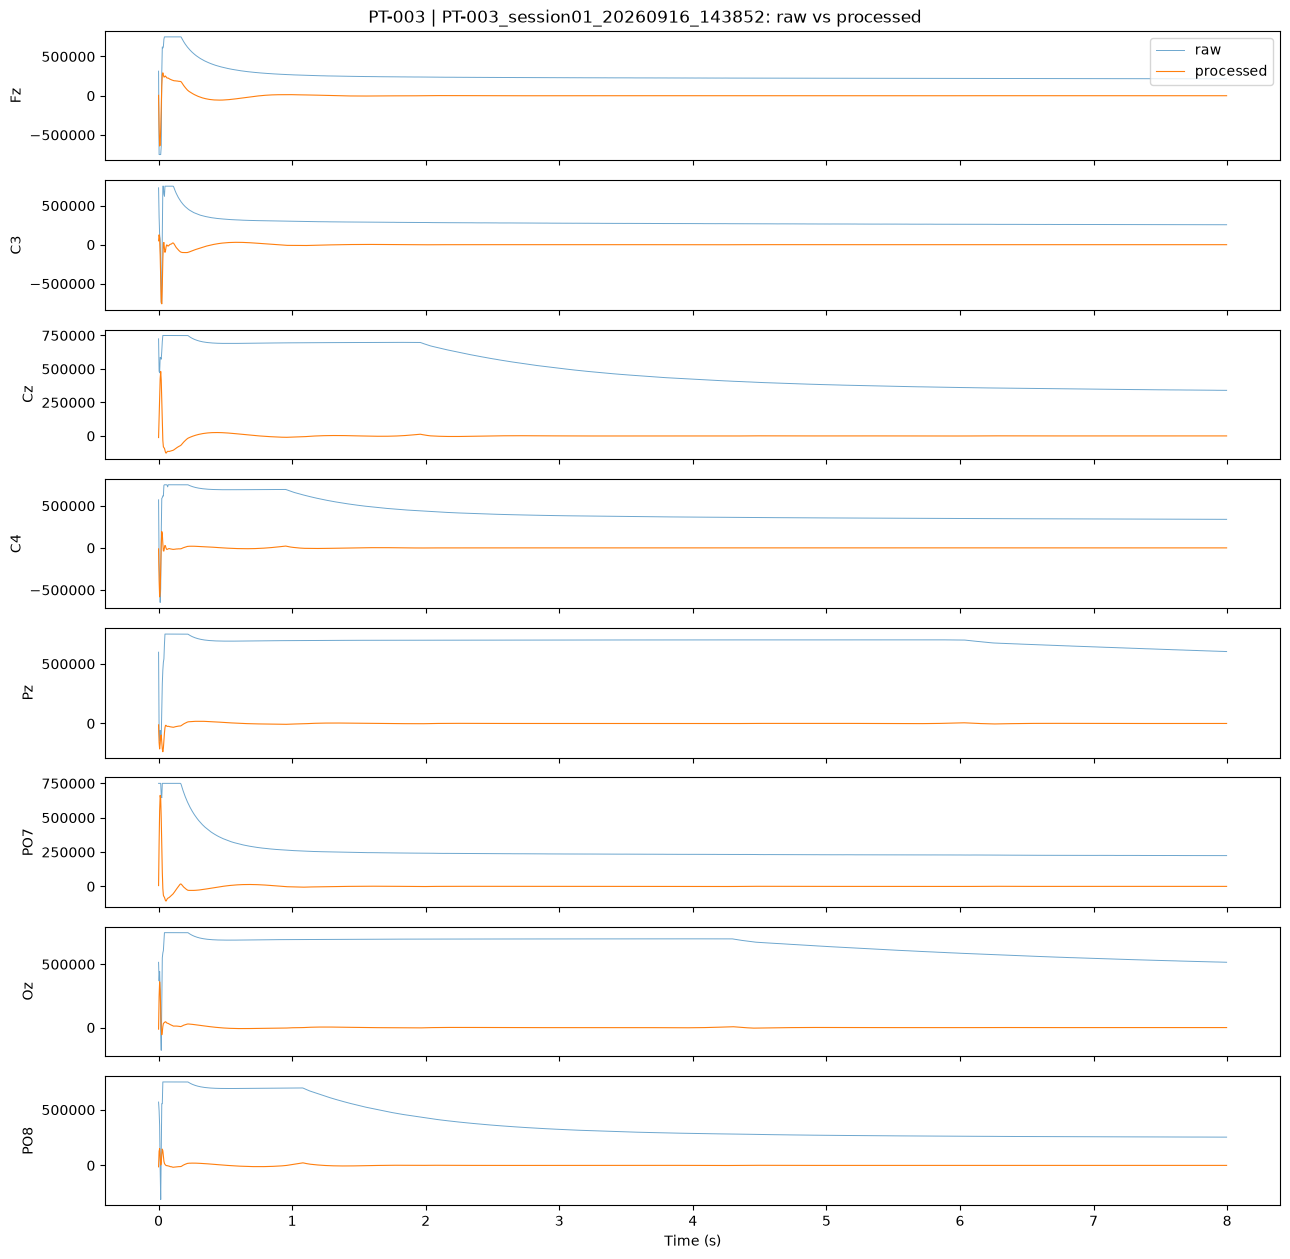

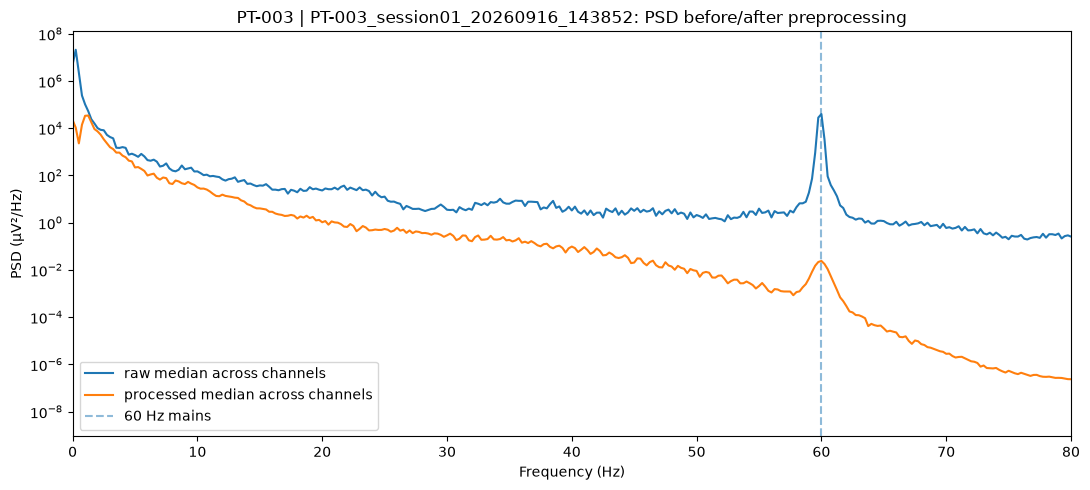

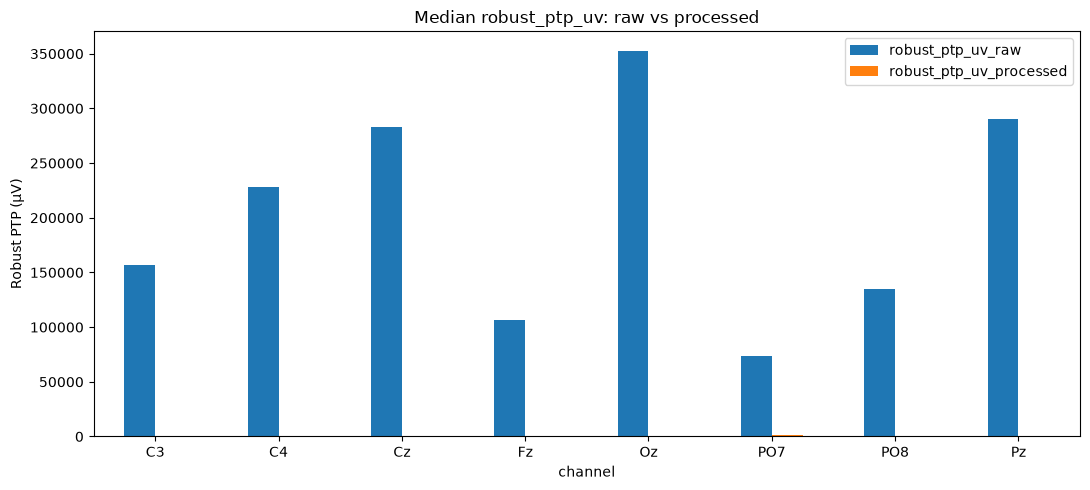

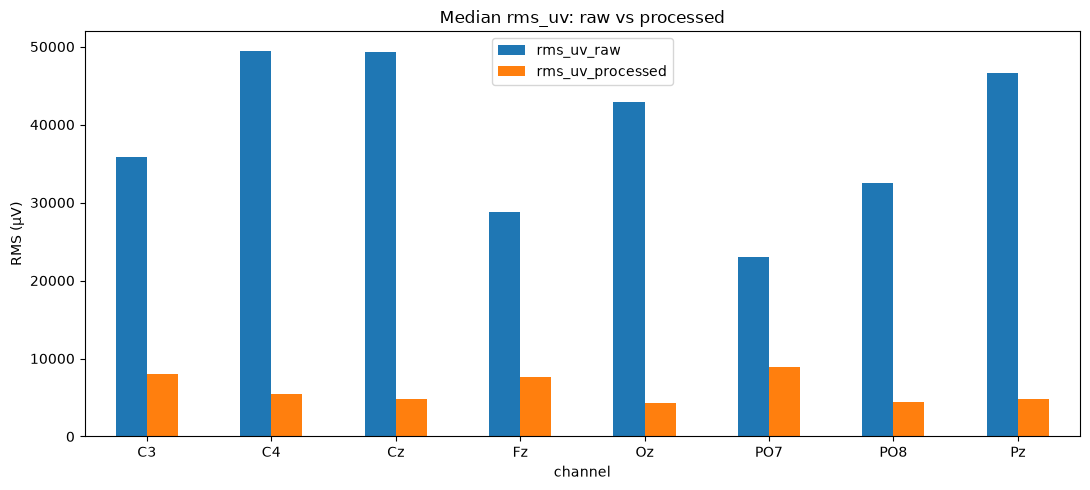

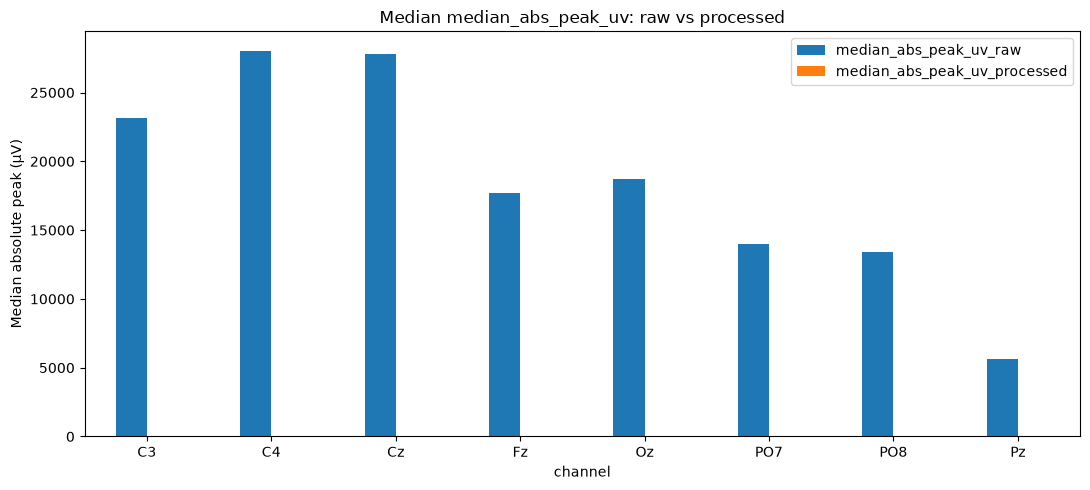

In [9]:

def plot_raw_vs_processed(rec, seconds=8, start_s=0):
    start = int(start_s * rec.sf)
    stop = min(rec.data_uv.shape[1], start + int(seconds * rec.sf))
    t = np.arange(stop - start) / rec.sf + start_s

    n = len(rec.names)
    fig, axes = plt.subplots(n, 1, figsize=(13, max(7, 1.6*n)), sharex=True)
    axes = np.atleast_1d(axes)

    for i, ax in enumerate(axes):
        ax.plot(
            t, rec.data_uv[i, start:stop],
            linewidth=0.7, alpha=0.65, label="raw"
        )
        ax.plot(
            t, rec.filtered_uv[i, start:stop],
            linewidth=0.8, label="processed"
        )
        ax.set_ylabel(rec.names[i])

        if i == 0:
            ax.legend(loc="upper right")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(
        f"{rec.participant} | {rec.session}: raw vs processed"
    )
    plt.tight_layout()
    plt.show()


def plot_psd_before_after(rec):
    f0, p0 = welch_psd(rec.data_uv, rec.sf)
    f1, p1 = welch_psd(rec.filtered_uv, rec.sf)

    plt.figure(figsize=(11, 5))
    plt.semilogy(
        f0, np.median(p0, axis=0),
        label="raw median across channels"
    )
    plt.semilogy(
        f1, np.median(p1, axis=0),
        label="processed median across channels"
    )
    plt.axvline(
        MAINS_HZ, linestyle="--", alpha=0.5,
        label=f"{MAINS_HZ:g} Hz mains"
    )
    plt.xlim(0, min(80, rec.sf / 2))
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD (µV²/Hz)")
    plt.title(
        f"{rec.participant} | {rec.session}: "
        "PSD before/after preprocessing"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_quality_before_after(metric, ylabel=None):
    if "QUALITY_COMPARISON" not in globals() or len(QUALITY_COMPARISON) == 0:
        print("No QC comparison data available.")
        return

    d = QUALITY_COMPARISON.groupby("channel")[
        [f"{metric}_raw", f"{metric}_processed"]
    ].median()

    ax = d.plot(kind="bar", figsize=(11, 5))
    ax.set_ylabel(ylabel or metric)
    ax.set_title(f"Median {metric}: raw vs processed")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


if RECORDINGS:
    plot_raw_vs_processed(RECORDINGS[0], seconds=8, start_s=0)
    plot_psd_before_after(RECORDINGS[0])

if "QUALITY_COMPARISON" in globals() and len(QUALITY_COMPARISON):
    plot_quality_before_after("robust_ptp_uv", "Robust PTP (µV)")
    plot_quality_before_after("rms_uv", "RMS (µV)")
    plot_quality_before_after("median_abs_peak_uv", "Median absolute peak (µV)")



## 8. Build 2-second epochs with span identity preserved

Each labeled span is split into 2-second windows. A 5-second movement span with 1-second step yields four candidate windows; a 7-second eye span yields six.

**Critical anti-leakage rule:** all windows from one span share one `span_id`. Cross-validation groups by `span_id`, so two overlapping windows from the same movement cannot appear on opposite sides of a train/test split.

### Additional motor-imagery literature comparison

For every **filtered 2-second epoch**, this notebook now also applies a simple literature-comparable amplitude screen:

\[
\max |EEG| > 100\ \mu V
\]

For each epoch it records:

- whether **any channel** exceeds ±100 µV;
- how many channels exceed ±100 µV;
- the fraction of channels exceeding ±100 µV;
- the overall and class-wise percentage of epochs exceeding the criterion.

This ±100 µV criterion is **reported separately** from the notebook's existing artifact-rejection rule. It is therefore a comparison/QC statistic, not an automatic reason to discard a window in this pipeline.


In [10]:

@dataclass
class EpochSet:
    X: np.ndarray                 # epochs x channels x samples
    y: np.ndarray
    groups: np.ndarray            # span IDs
    participants: np.ndarray
    sessions: np.ndarray
    recordings: np.ndarray
    starts_s: np.ndarray
    names: list[str]
    sf: float
    artifact_info: pd.DataFrame


def epoch_artifact_metrics(epoch):
    # epoch: channels x samples, already PREPROCESSED/FILTERED
    absmax = np.max(np.abs(epoch), axis=1)
    ptp = np.ptp(epoch, axis=1)
    maxstep = np.max(np.abs(np.diff(epoch, axis=1)), axis=1)
    std = np.std(epoch, axis=1)

    # Existing notebook-specific artifact rule.
    bad = (
        (absmax > MAX_ABS_UV)
        | (ptp > MAX_PTP_UV)
        | (maxstep > MAX_STEP_UV)
        | (std < FLAT_STD_UV)
    )

    # Additional motor-imagery literature-comparable amplitude screen.
    # This is REPORTED separately and does not itself control `keep`.
    mi_bad_channels = absmax > MI_ABS_THRESHOLD_UV

    return {
        "bad_channels": int(bad.sum()),
        "bad_channel_fraction": float(bad.mean()),
        "max_abs_uv": float(absmax.max()),
        "max_ptp_uv": float(ptp.max()),
        "max_step_uv": float(maxstep.max()),
        "min_std_uv": float(std.min()),

        # MI-style ±100 µV comparison fields
        "mi_threshold_uv": float(MI_ABS_THRESHOLD_UV),
        "mi_exceeding_channels": int(mi_bad_channels.sum()),
        "mi_exceeding_channel_fraction": float(mi_bad_channels.mean()),
        "mi_epoch_exceeds_100uv": bool(mi_bad_channels.any()),

        "keep": bool(bad.mean() <= MAX_BAD_CHANNEL_FRACTION),
    }


def build_epochs(recordings, labels=None):
    X, y, groups, participants, sessions, rec_ids, starts = [], [], [], [], [], [], []
    art_rows = []
    common_names = None
    common_sf = None

    for r_i, rec in enumerate(recordings):
        if common_names is None:
            common_names = list(rec.names)
            common_sf = float(rec.sf)
        if list(rec.names) != common_names:
            raise ValueError(
                "Channel names/order differ across recordings. Harmonize channels first.\n"
                f"Expected {common_names}, got {rec.names} in {rec.source}"
            )
        if abs(rec.sf - common_sf) > 1e-6:
            raise ValueError(
                f"Sampling rates differ ({common_sf} vs {rec.sf}). "
                "Resample before combining recordings."
            )

        nwin = int(round(WINDOW_SECONDS * rec.sf))
        step = int(round(STEP_SECONDS * rec.sf))
        offset = int(round(START_OFFSET_SECONDS * rec.sf))

        for a_i, ann in enumerate(rec.annotations):
            label = canonical_label(ann["label"])
            if labels is not None and label not in labels:
                continue
            if label not in CLASS_ORDER:
                continue

            s0 = max(0, int(round(ann["t_start"] * rec.sf)) + offset)
            s1 = min(rec.filtered_uv.shape[1], int(round(ann["t_end"] * rec.sf)))
            if s1 - s0 < nwin:
                continue

            span_id = f"{rec.participant}|{rec.session}|r{r_i}|a{a_i}|{label}"
            for s in range(s0, s1 - nwin + 1, step):
                ep = rec.filtered_uv[:, s:s+nwin]
                metrics = epoch_artifact_metrics(ep)

                row = {
                    "epoch_index_candidate": len(art_rows),
                    "participant": rec.participant,
                    "session": rec.session,
                    "recording": r_i,
                    "span_id": span_id,
                    "label": label,
                    "start_s": s / rec.sf,
                    **metrics,
                }
                art_rows.append(row)

                if not metrics["keep"]:
                    continue

                X.append(ep)
                y.append(label)
                groups.append(span_id)
                participants.append(rec.participant)
                sessions.append(rec.session)
                rec_ids.append(r_i)
                starts.append(s / rec.sf)

    if not X:
        return EpochSet(
            np.empty((0, 0, 0)), np.array([]), np.array([]), np.array([]),
            np.array([]), np.array([]), np.array([]),
            common_names or [], common_sf or SF_EXPECTED, pd.DataFrame(art_rows)
        )

    return EpochSet(
        np.stack(X),
        np.array(y),
        np.array(groups),
        np.array(participants),
        np.array(sessions),
        np.array(rec_ids),
        np.array(starts),
        common_names,
        common_sf,
        pd.DataFrame(art_rows),
    )


EPOCHS = build_epochs(RECORDINGS)

print("Kept epochs:", len(EPOCHS.y))
if len(EPOCHS.artifact_info):
    print("Candidate windows:", len(EPOCHS.artifact_info))
    print("Artifact rejection rate:",
          f"{100*(1-EPOCHS.artifact_info['keep'].mean()):.1f}%")
    display(EPOCHS.artifact_info.groupby("label").agg(
        candidate_windows=("keep", "size"),
        kept_windows=("keep", "sum"),
        keep_rate=("keep", "mean"),
        median_ptp_uv=("max_ptp_uv", "median"),
        median_step_uv=("max_step_uv", "median"),
        mi_epochs_over_100uv=("mi_epoch_exceeds_100uv", "sum"),
        mi_percent_epochs_over_100uv=(
            "mi_epoch_exceeds_100uv",
            lambda x: 100.0 * x.mean()
        ),
        median_mi_exceeding_channels=(
            "mi_exceeding_channels", "median"
        ),
    ).reindex(CLASS_ORDER).round(3))

if len(EPOCHS.y):
    count_table = pd.DataFrame({
        "label": EPOCHS.y,
        "span": EPOCHS.groups,
        "participant": EPOCHS.participants,
        "session": EPOCHS.sessions,
    }).groupby("label").agg(
        epochs=("label", "size"),
        independent_spans=("span", "nunique"),
        participants=("participant", "nunique"),
        sessions=("session", "nunique"),
    ).reindex(CLASS_ORDER)
    display(count_table)


Kept epochs: 411
Candidate windows: 411
Artifact rejection rate: 0.0%


,candidate_windows,kept_windows,keep_rate,median_ptp_uv,median_step_uv,mi_epochs_over_100uv,mi_percent_epochs_over_100uv,median_mi_exceeding_channels
label,,,,,,,,
Clenching Left Hand,51,51,1.0,59.949,7.281,2,3.922,0.0
Clenching Right Hand,65,65,1.0,59.626,7.560,0,0.000,0.0
Moving Left Leg,47,47,1.0,62.297,7.261,1,2.128,0.0
Moving Right Leg,58,58,1.0,61.866,7.862,2,3.448,0.0
Moving Tongue,46,46,1.0,60.088,6.910,0,0.000,0.0
Eye Open,76,76,1.0,64.804,7.323,3,3.947,0.0
Eye Close,68,68,1.0,58.375,7.736,0,0.000,0.0


,epochs,independent_spans,participants,sessions
label,,,,
Clenching Left Hand,51,12,1,2
Clenching Right Hand,65,12,1,2
Moving Left Leg,47,12,1,2
Moving Right Leg,58,12,1,2
Moving Tongue,46,12,1,2
Eye Open,76,12,1,2
Eye Close,68,11,1,2



### 8A. Motor-imagery amplitude QC: percentage of filtered 2-second epochs exceeding ±100 µV

This section reports the additional MI-style amplitude criterion independently of the notebook's normal artifact-rejection rule.

The primary quantity is:

> **Percentage of filtered 2-second candidate epochs in which at least one EEG channel has \(|EEG| > 100\ \mu V\).**

The notebook reports this:

- overall;
- by class;
- by session;
- by EEG channel.

Because an epoch can exceed ±100 µV on only one channel, the channel-wise table helps determine whether the problem is widespread or concentrated in one electrode.


MI-style filtered-epoch amplitude criterion: |EEG| > 100 µV
Overall: 8/411 candidate 2-s epochs (1.95%) exceed the criterion on at least one channel.

By class:


,candidate_epochs,epochs_exceeding_100uv,percent_epochs_exceeding_100uv,median_exceeding_channels,max_exceeding_channels,median_max_abs_uv,p95_max_abs_uv
label,,,,,,,
Clenching Left Hand,51,2,3.922,0.0,1,33.139,61.466
Clenching Right Hand,65,0,0.000,0.0,0,35.500,53.578
Moving Left Leg,47,1,2.128,0.0,1,35.500,59.152
Moving Right Leg,58,2,3.448,0.0,1,35.912,63.316
Moving Tongue,46,0,0.000,0.0,0,33.440,51.526
Eye Open,76,3,3.947,0.0,1,35.977,75.192
Eye Close,68,0,0.000,0.0,0,33.750,52.937



By participant/session:


candidate_epochs  \
participant session                                              
PT-003      PT-003_session01_20260916_143852               209   
            PT-003_session02_20260916_145957               202   

                                              epochs_exceeding_100uv  \
participant session                                                    
PT-003      PT-003_session01_20260916_143852                       2   
            PT-003_session02_20260916_145957                       6   

                                              percent_epochs_exceeding_100uv  \
participant session                                                            
PT-003      PT-003_session01_20260916_143852                           0.957   
            PT-003_session02_20260916_145957                           2.970   

                                              median_max_abs_uv  \
participant session                                               
PT-003      PT-003_session01_20260916_143852             34.724   
            PT-003_session02_20260916_145957             35.624   

                                              p95_max_abs_uv  
participant session                                           
PT-003      PT-003_session01_20260916_143852          53.578  
            PT-003_session02_20260916_145957          67.895


By EEG channel:


,channel_epochs,channel_epochs_exceeding_100uv,percent_channel_epochs_exceeding_100uv,median_epoch_max_abs_uv,p95_epoch_max_abs_uv
channel,,,,,
Fz,411,0,0.000,22.434,35.557
C3,411,3,0.730,21.431,45.265
Cz,411,0,0.000,21.581,36.341
C4,411,5,1.217,29.121,57.284
Pz,411,0,0.000,18.456,33.716
PO7,411,0,0.000,14.044,20.204
Oz,411,0,0.000,20.309,40.330
PO8,411,0,0.000,14.135,20.187


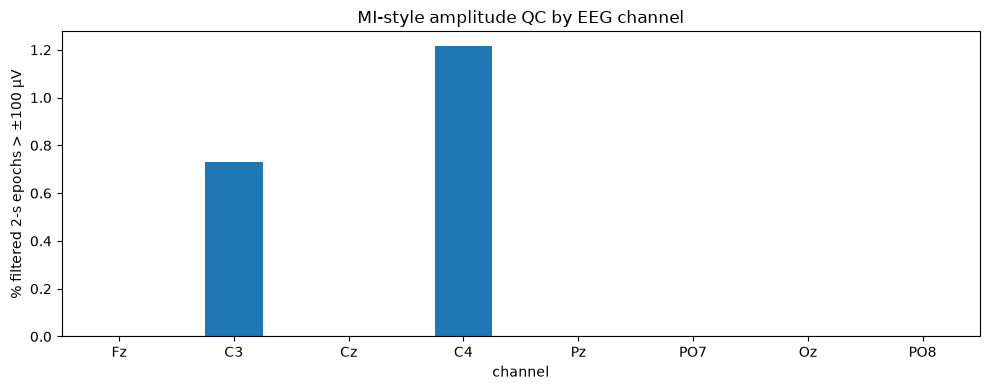

In [11]:

if len(EPOCHS.artifact_info):
    MI_EPOCH_QC = EPOCHS.artifact_info.copy()

    overall_n = len(MI_EPOCH_QC)
    overall_bad = int(MI_EPOCH_QC["mi_epoch_exceeds_100uv"].sum())
    overall_pct = 100.0 * MI_EPOCH_QC["mi_epoch_exceeds_100uv"].mean()

    print(
        f"MI-style filtered-epoch amplitude criterion: "
        f"|EEG| > {MI_ABS_THRESHOLD_UV:g} µV"
    )
    print(
        f"Overall: {overall_bad}/{overall_n} candidate 2-s epochs "
        f"({overall_pct:.2f}%) exceed the criterion on at least one channel."
    )

    MI_EPOCH_SUMMARY_BY_CLASS = (
        MI_EPOCH_QC.groupby("label")
        .agg(
            candidate_epochs=("mi_epoch_exceeds_100uv", "size"),
            epochs_exceeding_100uv=("mi_epoch_exceeds_100uv", "sum"),
            percent_epochs_exceeding_100uv=(
                "mi_epoch_exceeds_100uv",
                lambda x: 100.0 * x.mean()
            ),
            median_exceeding_channels=("mi_exceeding_channels", "median"),
            max_exceeding_channels=("mi_exceeding_channels", "max"),
            median_max_abs_uv=("max_abs_uv", "median"),
            p95_max_abs_uv=("max_abs_uv", lambda x: np.percentile(x, 95)),
        )
        .reindex(CLASS_ORDER)
    )

    print("\nBy class:")
    display(MI_EPOCH_SUMMARY_BY_CLASS.round(3))

    MI_EPOCH_SUMMARY_BY_SESSION = (
        MI_EPOCH_QC.groupby(["participant", "session"])
        .agg(
            candidate_epochs=("mi_epoch_exceeds_100uv", "size"),
            epochs_exceeding_100uv=("mi_epoch_exceeds_100uv", "sum"),
            percent_epochs_exceeding_100uv=(
                "mi_epoch_exceeds_100uv",
                lambda x: 100.0 * x.mean()
            ),
            median_max_abs_uv=("max_abs_uv", "median"),
            p95_max_abs_uv=("max_abs_uv", lambda x: np.percentile(x, 95)),
        )
    )

    print("\nBy participant/session:")
    display(MI_EPOCH_SUMMARY_BY_SESSION.round(3))

    # Channel-wise calculation directly from every filtered candidate epoch.
    channel_rows = []
    for r_i, rec in enumerate(RECORDINGS):
        nwin = int(round(WINDOW_SECONDS * rec.sf))
        step = int(round(STEP_SECONDS * rec.sf))
        offset = int(round(START_OFFSET_SECONDS * rec.sf))

        for a_i, ann in enumerate(rec.annotations):
            label = canonical_label(ann["label"])
            if label not in CLASS_ORDER:
                continue

            s0 = max(0, int(round(ann["t_start"] * rec.sf)) + offset)
            s1 = min(
                rec.filtered_uv.shape[1],
                int(round(ann["t_end"] * rec.sf))
            )
            if s1 - s0 < nwin:
                continue

            for s in range(s0, s1 - nwin + 1, step):
                ep = rec.filtered_uv[:, s:s+nwin]
                absmax = np.max(np.abs(ep), axis=1)

                for ch, ch_absmax in zip(rec.names, absmax):
                    channel_rows.append({
                        "participant": rec.participant,
                        "session": rec.session,
                        "recording": r_i,
                        "label": label,
                        "channel": ch,
                        "start_s": s / rec.sf,
                        "max_abs_uv": float(ch_absmax),
                        "exceeds_100uv": bool(
                            ch_absmax > MI_ABS_THRESHOLD_UV
                        ),
                    })

    MI_CHANNEL_QC = pd.DataFrame(channel_rows)

    if len(MI_CHANNEL_QC):
        MI_CHANNEL_SUMMARY = (
            MI_CHANNEL_QC.groupby("channel")
            .agg(
                channel_epochs=("exceeds_100uv", "size"),
                channel_epochs_exceeding_100uv=("exceeds_100uv", "sum"),
                percent_channel_epochs_exceeding_100uv=(
                    "exceeds_100uv",
                    lambda x: 100.0 * x.mean()
                ),
                median_epoch_max_abs_uv=("max_abs_uv", "median"),
                p95_epoch_max_abs_uv=(
                    "max_abs_uv",
                    lambda x: np.percentile(x, 95)
                ),
            )
            .reindex(EPOCHS.names)
        )

        print("\nBy EEG channel:")
        display(MI_CHANNEL_SUMMARY.round(3))

        ax = MI_CHANNEL_SUMMARY[
            "percent_channel_epochs_exceeding_100uv"
        ].plot(
            kind="bar",
            figsize=(10, 4),
            ylabel="% filtered 2-s epochs > ±100 µV",
            title="MI-style amplitude QC by EEG channel"
        )
        ax.axhline(0, linewidth=0.8)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
else:
    MI_EPOCH_QC = pd.DataFrame()
    MI_EPOCH_SUMMARY_BY_CLASS = pd.DataFrame()
    MI_EPOCH_SUMMARY_BY_SESSION = pd.DataFrame()
    MI_CHANNEL_QC = pd.DataFrame()
    MI_CHANNEL_SUMMARY = pd.DataFrame()
    print("No epochs available for MI-style amplitude QC.")



## 9. Feature extraction

Per channel, each 2-second window contributes:

- mean, standard deviation, RMS, robust peak-to-peak;
- line length and zero-crossing rate;
- skewness and kurtosis;
- Hjorth activity, mobility and complexity;
- spectral entropy;
- absolute and relative power in delta, theta, alpha/mu, beta and gamma;
- alpha/beta, theta/beta and beta/(alpha+theta) ratios.

A small number of cross-channel features are added for C3/C4 when those channels exist.


In [12]:

def hjorth_params(x):
    x = np.asarray(x, float)
    dx = np.diff(x)
    ddx = np.diff(dx)
    var0 = np.var(x)
    var1 = np.var(dx) if len(dx) else 0.0
    var2 = np.var(ddx) if len(ddx) else 0.0
    mobility = np.sqrt(var1 / max(var0, 1e-20))
    complexity = np.sqrt(var2 / max(var1, 1e-20)) / max(mobility, 1e-20)
    return var0, mobility, complexity


def spectral_entropy_from_psd(p):
    p = np.asarray(p, float)
    p = p / max(p.sum(), 1e-20)
    return float(-np.sum(p * np.log2(np.maximum(p, 1e-20))) / np.log2(len(p)))


def epoch_features(epoch, sf, names):
    feats = {}
    f, psd = welch_psd(epoch, sf, nperseg_s=WINDOW_SECONDS)

    for i, ch in enumerate(names):
        x = epoch[i]
        xc = x - np.mean(x)
        prefix = ch.replace(" ", "_")

        feats[f"{prefix}__mean"] = float(np.mean(xc))
        feats[f"{prefix}__std"] = float(np.std(xc))
        feats[f"{prefix}__rms"] = float(np.sqrt(np.mean(xc**2)))
        feats[f"{prefix}__ptp"] = float(np.ptp(xc))
        feats[f"{prefix}__line_length"] = float(np.mean(np.abs(np.diff(xc))))
        feats[f"{prefix}__zcr"] = float(np.mean(np.diff(np.signbit(xc)) != 0))
        feats[f"{prefix}__skew"] = float(stats.skew(xc, bias=False)) if len(xc) > 3 else 0.0
        feats[f"{prefix}__kurtosis"] = float(stats.kurtosis(xc, fisher=True, bias=False)) if len(xc) > 3 else 0.0

        activity, mobility, complexity = hjorth_params(xc)
        feats[f"{prefix}__hjorth_activity"] = activity
        feats[f"{prefix}__hjorth_mobility"] = mobility
        feats[f"{prefix}__hjorth_complexity"] = complexity

        band_abs = {}
        total = band_integral(f, psd[i], 1.0, 45.0)
        for band, (lo, hi) in BANDS.items():
            bp = band_integral(f, psd[i], lo, hi)
            band_abs[band] = bp
            feats[f"{prefix}__{band}_abs"] = bp
            feats[f"{prefix}__{band}_rel"] = bp / max(total, 1e-20)

        inband = (f >= 1.0) & (f <= 45.0)
        feats[f"{prefix}__spectral_entropy"] = spectral_entropy_from_psd(psd[i, inband])

        alpha = band_abs["alpha_mu"]
        beta = band_abs["beta"]
        theta = band_abs["theta"]
        feats[f"{prefix}__alpha_beta"] = alpha / max(beta, 1e-20)
        feats[f"{prefix}__theta_beta"] = theta / max(beta, 1e-20)
        feats[f"{prefix}__engagement"] = beta / max(alpha + theta, 1e-20)

    # Lateralized central features are especially useful for hand/leg tasks.
    if "C3" in names and "C4" in names:
        i3, i4 = names.index("C3"), names.index("C4")
        for band, (lo, hi) in {"alpha_mu": (8, 13), "beta": (13, 30)}.items():
            p3 = band_integral(f, psd[i3], lo, hi)
            p4 = band_integral(f, psd[i4], lo, hi)
            feats[f"lateral__{band}_C3_minus_C4"] = p3 - p4
            feats[f"lateral__{band}_log_C3_over_C4"] = np.log(
                max(p3, 1e-20) / max(p4, 1e-20)
            )

    return feats


FEATURE_ROWS = []
if len(EPOCHS.y):
    for i, ep in enumerate(EPOCHS.X):
        d = epoch_features(ep, EPOCHS.sf, EPOCHS.names)
        d.update({
            "epoch": i,
            "label": EPOCHS.y[i],
            "group": EPOCHS.groups[i],
            "participant": EPOCHS.participants[i],
            "session": EPOCHS.sessions[i],
            "recording": EPOCHS.recordings[i],
            "start_s": EPOCHS.starts_s[i],
        })
        FEATURE_ROWS.append(d)

FEATURES = pd.DataFrame(FEATURE_ROWS)
print("Feature matrix shape:", FEATURES.shape)
if len(FEATURES):
    display(FEATURES.head())


Feature matrix shape: (411, 211)


,Fz__mean,Fz__std,Fz__rms,Fz__ptp,Fz__line_length,Fz__zcr,Fz__skew,Fz__kurtosis,Fz__hjorth_activity,Fz__hjorth_mobility,Fz__hjorth_complexity,Fz__delta_abs,Fz__delta_rel,Fz__theta_abs,Fz__theta_rel,Fz__alpha_mu_abs,Fz__alpha_mu_rel,Fz__beta_abs,Fz__beta_rel,Fz__gamma_abs,Fz__gamma_rel,Fz__spectral_entropy,Fz__alpha_beta,Fz__theta_beta,Fz__engagement,C3__mean,C3__std,C3__rms,C3__ptp,C3__line_length,C3__zcr,C3__skew,C3__kurtosis,C3__hjorth_activity,C3__hjorth_mobility,C3__hjorth_complexity,C3__delta_abs,C3__delta_rel,C3__theta_abs,C3__theta_rel,C3__alpha_mu_abs,C3__alpha_mu_rel,C3__beta_abs,C3__beta_rel,C3__gamma_abs,C3__gamma_rel,C3__spectral_entropy,C3__alpha_beta,C3__theta_beta,C3__engagement,Cz__mean,Cz__std,Cz__rms,Cz__ptp,Cz__line_length,Cz__zcr,Cz__skew,Cz__kurtosis,Cz__hjorth_activity,Cz__hjorth_mobility,Cz__hjorth_complexity,Cz__delta_abs,Cz__delta_rel,Cz__theta_abs,Cz__theta_rel,Cz__alpha_mu_abs,Cz__alpha_mu_rel,Cz__beta_abs,Cz__beta_rel,Cz__gamma_abs,Cz__gamma_rel,Cz__spectral_entropy,Cz__alpha_beta,Cz__theta_beta,Cz__engagement,C4__mean,C4__std,C4__rms,C4__ptp,C4__line_length,C4__zcr,C4__skew,C4__kurtosis,C4__hjorth_activity,C4__hjorth_mobility,C4__hjorth_complexity,C4__delta_abs,C4__delta_rel,C4__theta_abs,C4__theta_rel,C4__alpha_mu_abs,C4__alpha_mu_rel,C4__beta_abs,C4__beta_rel,C4__gamma_abs,C4__gamma_rel,C4__spectral_entropy,C4__alpha_beta,C4__theta_beta,C4__engagement,...,Pz__delta_abs,Pz__delta_rel,Pz__theta_abs,Pz__theta_rel,Pz__alpha_mu_abs,Pz__alpha_mu_rel,Pz__beta_abs,Pz__beta_rel,Pz__gamma_abs,Pz__gamma_rel,Pz__spectral_entropy,Pz__alpha_beta,Pz__theta_beta,Pz__engagement,PO7__mean,PO7__std,PO7__rms,PO7__ptp,PO7__line_length,PO7__zcr,PO7__skew,PO7__kurtosis,PO7__hjorth_activity,PO7__hjorth_mobility,PO7__hjorth_complexity,PO7__delta_abs,PO7__delta_rel,PO7__theta_abs,PO7__theta_rel,PO7__alpha_mu_abs,PO7__alpha_mu_rel,PO7__beta_abs,PO7__beta_rel,PO7__gamma_abs,PO7__gamma_rel,PO7__spectral_entropy,PO7__alpha_beta,PO7__theta_beta,PO7__engagement,Oz__mean,Oz__std,Oz__rms,Oz__ptp,Oz__line_length,Oz__zcr,Oz__skew,Oz__kurtosis,Oz__hjorth_activity,Oz__hjorth_mobility,Oz__hjorth_complexity,Oz__delta_abs,Oz__delta_rel,Oz__theta_abs,Oz__theta_rel,Oz__alpha_mu_abs,Oz__alpha_mu_rel,Oz__beta_abs,Oz__beta_rel,Oz__gamma_abs,Oz__gamma_rel,Oz__spectral_entropy,Oz__alpha_beta,Oz__theta_beta,Oz__engagement,PO8__mean,PO8__std,PO8__rms,PO8__ptp,PO8__line_length,PO8__zcr,PO8__skew,PO8__kurtosis,PO8__hjorth_activity,PO8__hjorth_mobility,PO8__hjorth_complexity,PO8__delta_abs,PO8__delta_rel,PO8__theta_abs,PO8__theta_rel,PO8__alpha_mu_abs,PO8__alpha_mu_rel,PO8__beta_abs,PO8__beta_rel,PO8__gamma_abs,PO8__gamma_rel,PO8__spectral_entropy,PO8__alpha_beta,PO8__theta_beta,PO8__engagement,lateral__alpha_mu_C3_minus_C4,lateral__alpha_mu_log_C3_over_C4,lateral__beta_C3_minus_C4,lateral__beta_log_C3_over_C4,epoch,label,group,participant,session,recording,start_s
0,0.000000e+00,15.181689,15.181689,72.691630,2.508944,0.062124,0.028381,-0.220499,230.483693,0.211986,1.510401,21.411822,0.095277,42.449860,0.188891,134.357141,0.597856,4.313632,0.019195,0.607926,0.002705,0.577802,31.147102,9.840862,0.024397,2.842171e-17,15.885331,15.885331,80.742395,2.451188,0.048096,-0.237334,-0.538197,252.343731,0.189966,1.831858,28.317465,0.123365,77.875791,0.339267,96.015271,0.418292,5.174143,0.022541,0.754223,0.003286,0.603176,18.556750,15.050955,0.029755,-1.278977e-16,9.581634,9.581634,55.190440,2.339798,0.090180,0.172946,0.440489,91.807713,0.318963,1.454694,11.561370,0.150587,3.268933,0.042578,19.127083,0.249131,37.198662,0.484514,1.479759,0.019274,0.724137,0.514187,0.087878,1.660950,-1.136868e-16,6.361410,6.361410,35.616105,1.029651,0.070140,0.596644,0.695001,40.467541,0.204270,2.219609,22.416943,0.473695,4.745629,0.100280,15.224076,0.321702,1.468645,0.031034,0.391337,0.008269,0.630894,10.366067,3.231297,0.073544,...,24.130620,0.396059,4.297264,0.070532,25.540791,0.419205,1.363195,0.022374,0.286260,0.004698,0.619463,18.735978,3.152347,0.045686,1.705303e-16,5.676


## 10. ERD/ERS

Two views are provided.

### A. Condition-reference ERD/ERS
Uses **Eye Open** as a resting reference:

\[
ERD/ERS(\%) = 100\frac{P_{task}-P_{EyeOpen}}{P_{EyeOpen}}
\]

- negative = ERD (band power decreased);
- positive = ERS (band power increased).

This is useful for comparing conditions, but it is not a perfectly cue-locked event-related baseline.

### B. Cue-locked ERD/ERS
If each annotation's start time is the actual movement cue/onset, the notebook also compares a **pre-cue interval from the same event** against a post-cue interval. This is the stronger event-related interpretation.

For motor activity, focus primarily on **alpha/mu (8–13 Hz)** and **beta (13–30 Hz)**, especially C3/Cz/C4 when available.


In [13]:

def mean_band_power(epoch, sf, lo, hi):
    f, p = welch_psd(epoch, sf, nperseg_s=min(WINDOW_SECONDS, 2.0))
    vals = np.array([band_integral(f, p[i], lo, hi) for i in range(epoch.shape[0])])
    return vals


def condition_reference_erds(epochs: EpochSet, baseline_label="Eye Open"):
    if len(epochs.y) == 0:
        return pd.DataFrame()

    rows = []
    base_idx = np.where(epochs.y == baseline_label)[0]
    if len(base_idx) == 0:
        print("No Eye Open epochs available for condition-reference ERD/ERS.")
        return pd.DataFrame()

    # Use median baseline power for robustness.
    baseline = {}
    for band, (lo, hi) in {"alpha_mu": (8, 13), "beta": (13, 30)}.items():
        bp = np.array([mean_band_power(epochs.X[i], epochs.sf, lo, hi) for i in base_idx])
        baseline[band] = np.median(bp, axis=0)

    for label in CLASS_ORDER:
        idx = np.where(epochs.y == label)[0]
        if len(idx) == 0:
            continue
        for band, (lo, hi) in {"alpha_mu": (8, 13), "beta": (13, 30)}.items():
            bp = np.array([mean_band_power(epochs.X[i], epochs.sf, lo, hi) for i in idx])
            task = np.median(bp, axis=0)
            erds = 100.0 * (task - baseline[band]) / np.maximum(baseline[band], 1e-20)
            for ch, value in zip(epochs.names, erds):
                rows.append({
                    "label": label,
                    "band": band,
                    "channel": ch,
                    "erds_percent": float(value),
                })
    return pd.DataFrame(rows)


ERDS_CONDITION = condition_reference_erds(EPOCHS)
if len(ERDS_CONDITION):
    display(
        ERDS_CONDITION[
            ERDS_CONDITION["channel"].isin([c for c in CENTRAL_CHANNELS if c in EPOCHS.names])
        ].pivot_table(index=["label", "channel"], columns="band",
                      values="erds_percent").round(1)
    )


band                          alpha_mu  beta
label                channel                
Clenching Left Hand  C3           -3.4   3.7
                     C4          -11.4  11.1
                     Cz            6.5  15.2
Clenching Right Hand C3            6.6   9.4
                     C4            4.8   3.3
                     Cz           25.1  27.9
Eye Close            C3           23.4   0.4
                     C4          -26.4   8.4
                     Cz          -12.4  -3.9
Eye Open             C3            0.0   0.0
                     C4            0.0   0.0
                     Cz            0.0   0.0
Moving Left Leg      C3           -1.8   1.7
                     C4           -9.0   0.5
                     Cz           -6.2  -4.9
Moving Right Leg     C3           -4.2   7.3
                     C4           12.2   6.0
                     Cz           -1.4   6.7
Moving Tongue        C3          -18.8   3.5
                     C4           18.1   6.7
                     Cz            8.8  -7.6

In [14]:

def cue_locked_erds(
    recordings,
    baseline=(-1.5, -0.25),
    task=(0.5, 2.5),
    labels=("Clenching Left Hand", "Clenching Right Hand",
            "Moving Left Leg", "Moving Right Leg", "Moving Tongue"),
):
    rows = []
    for r_i, rec in enumerate(recordings):
        for a_i, ann in enumerate(rec.annotations):
            label = canonical_label(ann["label"])
            if label not in labels:
                continue

            onset = ann["t_start"]
            b0 = int(round((onset + baseline[0]) * rec.sf))
            b1 = int(round((onset + baseline[1]) * rec.sf))
            t0 = int(round((onset + task[0]) * rec.sf))
            t1 = int(round((onset + task[1]) * rec.sf))

            if b0 < 0 or t1 > rec.filtered_uv.shape[1] or b1 <= b0 or t1 <= t0:
                continue

            xb = rec.filtered_uv[:, b0:b1]
            xt = rec.filtered_uv[:, t0:t1]

            for band, (lo, hi) in {"alpha_mu": (8, 13), "beta": (13, 30)}.items():
                pb = mean_band_power(xb, rec.sf, lo, hi)
                pt = mean_band_power(xt, rec.sf, lo, hi)
                erds = 100 * (pt - pb) / np.maximum(pb, 1e-20)

                for ch, value in zip(rec.names, erds):
                    rows.append({
                        "participant": rec.participant,
                        "session": rec.session,
                        "recording": r_i,
                        "event": f"r{r_i}_a{a_i}",
                        "label": label,
                        "band": band,
                        "channel": ch,
                        "erds_percent": float(value),
                    })

    return pd.DataFrame(rows)


ERDS_CUE = cue_locked_erds(RECORDINGS)
print("Cue-locked ERD/ERS events:", ERDS_CUE["event"].nunique() if len(ERDS_CUE) else 0)

if len(ERDS_CUE):
    central = [c for c in CENTRAL_CHANNELS if c in ERDS_CUE["channel"].unique()]
    summary = (
        ERDS_CUE[ERDS_CUE["channel"].isin(central)]
        .groupby(["label", "channel", "band"])["erds_percent"]
        .agg(["mean", "median", "std", "count"])
        .round(1)
    )
    display(summary)


Cue-locked ERD/ERS events: 60


mean  median    std  count
label                channel band                                
Clenching Left Hand  C3      alpha_mu  35.6    10.6   97.0     12
                             beta      31.5    19.6   63.5     12
                     C4      alpha_mu  37.0    24.0   84.3     12
                             beta      34.3    33.4   56.3     12
                     Cz      alpha_mu  -3.2   -15.6   36.2     12
                             beta      50.1    23.2   64.8     12
Clenching Right Hand C3      alpha_mu  51.2     7.7  160.8     12
                             beta      46.1    44.4   47.8     12
                     C4      alpha_mu  39.1    44.1   52.2     12
                             beta      18.0    17.0   41.9     12
                     Cz      alpha_mu  77.1    51.6   78.8     12
                             beta      13.8     0.9   69.7     12
Moving Left Leg      C3      alpha_mu  21.6    -0.7   92.3     12
                             beta      -2.2   -13.6   50.4     12
                     C4      alpha_mu  49.7    24.2   72.8     12
                             beta      37.3     8.8   65.9     12
                     Cz      alpha_mu  10.0    -2.4   75.2     12
                             beta      49.5    28.5   67.8     12
Moving Right Leg     C3      alpha_mu  84.5     3.9  183.0     12
                             beta      57.4     7.8  126.2     12
                     C4      alpha_mu  52.9    11.1  113.0     12
                             beta      30.8   -10.6  146.0     12
                     Cz      alpha_mu  51.4     5.8  150.2     12
                             beta      24.5    12.1   69.5     12
Moving Tongue        C3      alpha_mu   6.2   -26.7   84.5     12
                             beta       9.5    -5.9   51.1     12
                     C4      alpha_mu  18.2     9.7   64.2     12
                             beta      30.9    39.9   38.1     12
                     Cz      alpha_mu  61.3    -2.0  136.7     12
                             beta       8.7     2.5   51.0     12

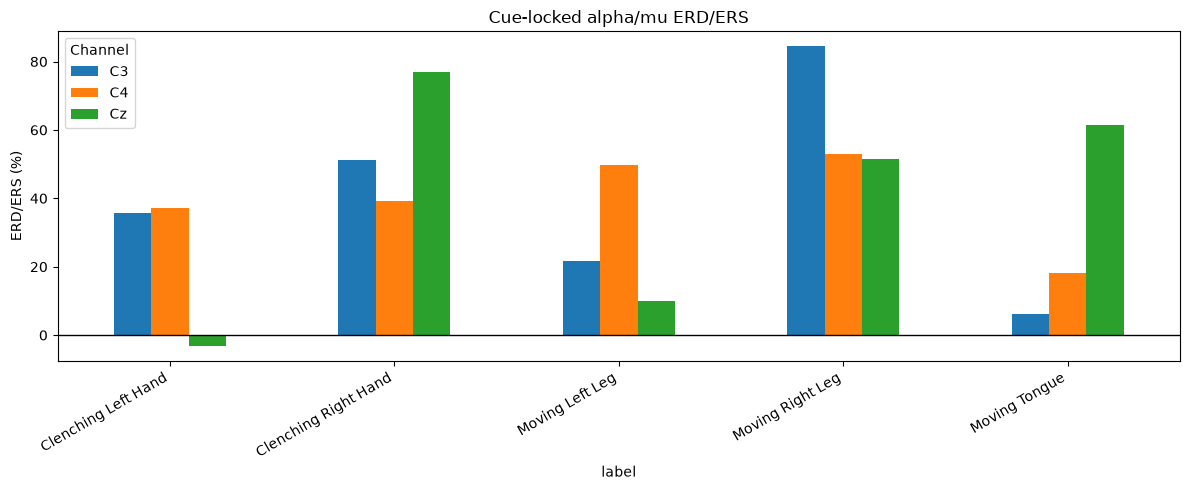

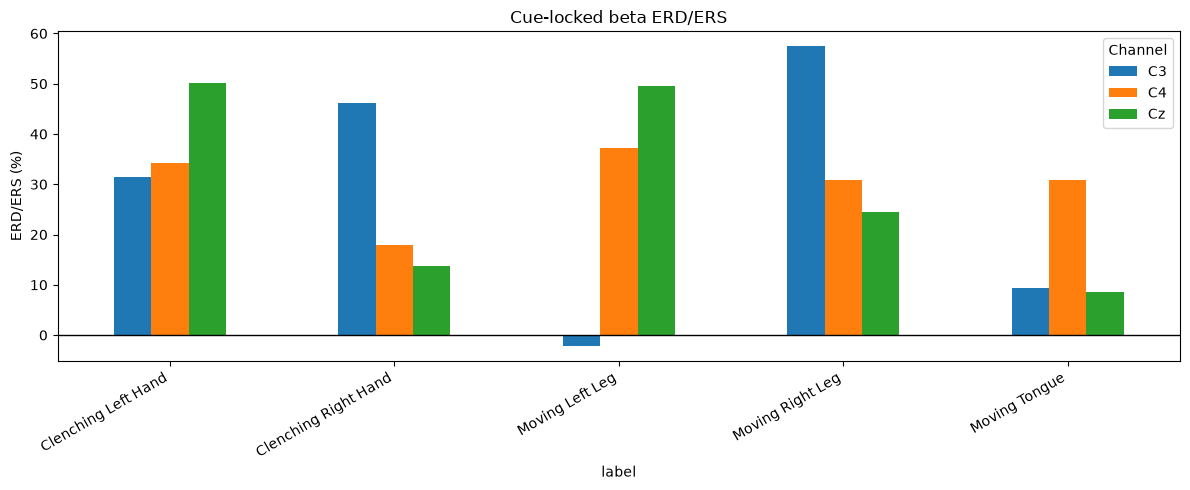

In [15]:

def plot_erds(df, band="alpha_mu", channels=None, title=None):
    if df is None or len(df) == 0:
        print("No ERD/ERS data to plot.")
        return
    if channels is None:
        channels = [c for c in CENTRAL_CHANNELS if c in df["channel"].unique()]
        if not channels:
            channels = sorted(df["channel"].unique())

    d = df[(df["band"] == band) & (df["channel"].isin(channels))]
    if len(d) == 0:
        return

    pivot = d.groupby(["label", "channel"])["erds_percent"].mean().unstack("channel")
    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.axhline(0, linewidth=1, color="black")
    ax.set_ylabel("ERD/ERS (%)")
    ax.set_title(title or f"{band} ERD/ERS: negative=ERD, positive=ERS")
    ax.legend(title="Channel")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

if len(ERDS_CUE):
    plot_erds(ERDS_CUE, "alpha_mu", title="Cue-locked alpha/mu ERD/ERS")
    plot_erds(ERDS_CUE, "beta", title="Cue-locked beta ERD/ERS")
elif len(ERDS_CONDITION):
    plot_erds(ERDS_CONDITION, "alpha_mu", title="Condition-reference alpha/mu ERD/ERS")
    plot_erds(ERDS_CONDITION, "beta", title="Condition-reference beta ERD/ERS")



## 11. Leakage-aware feature-model evaluation

Models:

- shrinkage LDA;
- logistic regression;
- RBF SVM;
- random forest.

`SelectKBest` and `StandardScaler` are fitted **inside each training fold**.

Metrics:

- **balanced accuracy** — preferred when class counts differ;
- **macro-F1** — weights every class equally;
- confusion matrix;
- per-class precision/recall/F1.

The number of CV folds is limited by the number of independent labeled spans available in the smallest class.


In [16]:

META_COLS = {
    "epoch", "label", "group", "participant", "session",
    "recording", "start_s"
}

def task_frame(task_name):
    labels = TASKS[task_name]
    d = FEATURES[FEATURES["label"].isin(labels)].copy()
    feature_cols = [c for c in d.columns if c not in META_COLS]
    X = d[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(float)
    y = d["label"].to_numpy()
    groups = d["group"].to_numpy()
    return d, X, y, groups, feature_cols


def choose_group_cv(y, groups, max_splits=5):
    temp = pd.DataFrame({"y": y, "g": groups}).drop_duplicates()
    groups_per_class = temp.groupby("y")["g"].nunique()
    if len(groups_per_class) < 2 or groups_per_class.min() < 2:
        raise ValueError(
            "Need at least 2 independent spans per class for group-aware evaluation. "
            f"Current independent spans per class: {groups_per_class.to_dict()}"
        )
    n_splits = int(min(max_splits, groups_per_class.min()))
    return StratifiedGroupKFold(
        n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE
    ), n_splits


def make_models(n_features):
    k = min(40, n_features)
    return {
        "LDA": Pipeline([
            ("select", SelectKBest(f_classif, k=k)),
            ("scale", StandardScaler()),
            ("model", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]),
        "LogisticRegression": Pipeline([
            ("select", SelectKBest(f_classif, k=k)),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE
            )),
        ]),
        "SVM_RBF": Pipeline([
            ("select", SelectKBest(f_classif, k=k)),
            ("scale", StandardScaler()),
            ("model", SVC(C=2.0, kernel="rbf", gamma="scale", class_weight="balanced")),
        ]),
        "RandomForest": Pipeline([
            ("select", SelectKBest(f_classif, k=k)),
            ("model", RandomForestClassifier(
                n_estimators=500, min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE, n_jobs=-1
            )),
        ]),
    }


def evaluate_task(task_name):
    d, X, y, groups, feature_cols = task_frame(task_name)
    if len(np.unique(y)) != len(TASKS[task_name]):
        missing = sorted(set(TASKS[task_name]) - set(y))
        raise ValueError(f"{task_name}: missing classes {missing}")

    cv, n_splits = choose_group_cv(y, groups)
    models = make_models(X.shape[1])

    summary_rows = []
    details = {}
    labels = TASKS[task_name]

    for model_name, model in models.items():
        y_true_all, y_pred_all = [], []
        fold_rows = []

        for fold, (tr, te) in enumerate(cv.split(X, y, groups)):
            fit = clone(model).fit(X[tr], y[tr])
            pred = fit.predict(X[te])

            fold_rows.append({
                "task": task_name,
                "model": model_name,
                "fold": fold,
                "n_train": len(tr),
                "n_test": len(te),
                "train_spans": len(np.unique(groups[tr])),
                "test_spans": len(np.unique(groups[te])),
                "balanced_accuracy": balanced_accuracy_score(y[te], pred),
                "macro_f1": f1_score(y[te], pred, average="macro"),
            })
            y_true_all.extend(y[te])
            y_pred_all.extend(pred)

        folds = pd.DataFrame(fold_rows)
        cm = confusion_matrix(y_true_all, y_pred_all, labels=labels)
        report = classification_report(
            y_true_all, y_pred_all, labels=labels,
            output_dict=True, zero_division=0
        )

        summary_rows.append({
            "task": task_name,
            "model": model_name,
            "cv_folds": n_splits,
            "epochs": len(y),
            "spans": len(np.unique(groups)),
            "balanced_accuracy_mean": folds["balanced_accuracy"].mean(),
            "balanced_accuracy_std": folds["balanced_accuracy"].std(ddof=1),
            "macro_f1_mean": folds["macro_f1"].mean(),
            "macro_f1_std": folds["macro_f1"].std(ddof=1),
        })
        details[model_name] = {
            "folds": folds,
            "cm": cm,
            "report": report,
            "y_true": np.array(y_true_all),
            "y_pred": np.array(y_pred_all),
            "labels": labels,
            "feature_cols": feature_cols,
        }

    return pd.DataFrame(summary_rows), details


ALL_RESULTS = {}
for task_name in TASKS:
    print("\n" + "="*80)
    print("TASK:", task_name, "->", TASKS[task_name])
    try:
        summary, details = evaluate_task(task_name)
        ALL_RESULTS[task_name] = {"summary": summary, "details": details}
        display(summary.sort_values(
            ["balanced_accuracy_mean", "macro_f1_mean"], ascending=False
        ).round(3))
    except Exception as e:
        print("Skipped:", e)



TASK: all_7 -> ['Clenching Left Hand', 'Clenching Right Hand', 'Moving Left Leg', 'Moving Right Leg', 'Moving Tongue', 'Eye Open', 'Eye Close']


,task,model,cv_folds,epochs,spans,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
1,all_7,LogisticRegression,5,411,83,0.113,0.046,0.110,0.042
3,all_7,RandomForest,5,411,83,0.112,0.050,0.099,0.042
0,all_7,LDA,5,411,83,0.108,0.045,0.100,0.042
2,all_7,SVM_RBF,5,411,83,0.094,0.054,0.092,0.050



TASK: hand_L_vs_R -> ['Clenching Left Hand', 'Clenching Right Hand']


,task,model,cv_folds,epochs,spans,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
1,hand_L_vs_R,LogisticRegression,5,116,24,0.498,0.076,0.483,0.084
0,hand_L_vs_R,LDA,5,116,24,0.442,0.038,0.428,0.040
3,hand_L_vs_R,RandomForest,5,116,24,0.403,0.176,0.387,0.180
2,hand_L_vs_R,SVM_RBF,5,116,24,0.330,0.152,0.311,0.150



TASK: leg_L_vs_R -> ['Moving Left Leg', 'Moving Right Leg']


,task,model,cv_folds,epochs,spans,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
3,leg_L_vs_R,RandomForest,5,105,24,0.516,0.043,0.496,0.067
0,leg_L_vs_R,LDA,5,105,24,0.490,0.101,0.482,0.105
1,leg_L_vs_R,LogisticRegression,5,105,24,0.480,0.074,0.472,0.079
2,leg_L_vs_R,SVM_RBF,5,105,24,0.478,0.055,0.467,0.052



TASK: tongue_vs_eye_states -> ['Moving Tongue', 'Eye Close', 'Eye Open']


,task,model,cv_folds,epochs,spans,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
2,tongue_vs_eye_states,SVM_RBF,5,190,35,0.368,0.095,0.356,0.094
0,tongue_vs_eye_states,LDA,5,190,35,0.332,0.024,0.315,0.028
3,tongue_vs_eye_states,RandomForest,5,190,35,0.326,0.048,0.311,0.045
1,tongue_vs_eye_states,LogisticRegression,5,190,35,0.295,0.046,0.277,0.039



 all_7 | inspected model: LogisticRegression


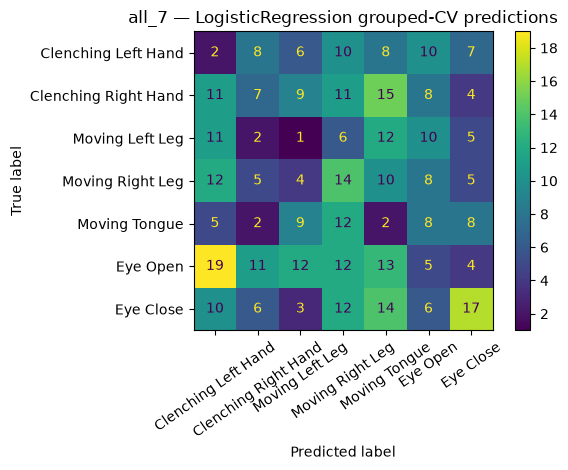

,precision,recall,f1-score,support
Clenching Left Hand,0.029,0.039,0.033,51.000
Clenching Right Hand,0.171,0.108,0.132,65.000
Moving Left Leg,0.023,0.021,0.022,47.000
Moving Right Leg,0.182,0.241,0.207,58.000
Moving Tongue,0.027,0.043,0.033,46.000
Eye Open,0.091,0.066,0.076,76.000
Eye Close,0.340,0.250,0.288,68.000
accuracy,0.117,0.117,0.117,0.117
macro avg,0.123,0.110,0.113,411.000
weighted avg,0.135,0.117,0.122,411.000



 hand_L_vs_R | inspected model: LogisticRegression


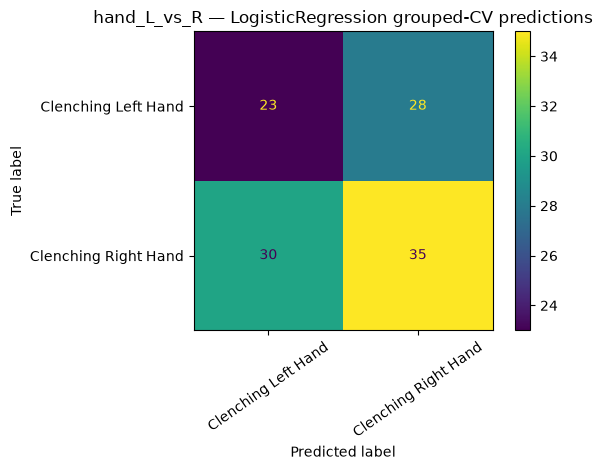

,precision,recall,f1-score,support
Clenching Left Hand,0.434,0.451,0.442,51.0
Clenching Right Hand,0.556,0.538,0.547,65.0
accuracy,0.500,0.500,0.500,0.5
macro avg,0.495,0.495,0.495,116.0
weighted avg,0.502,0.500,0.501,116.0



 leg_L_vs_R | inspected model: RandomForest


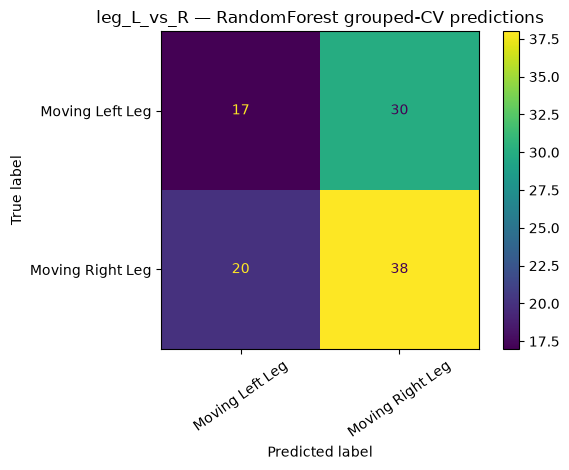

,precision,recall,f1-score,support
Moving Left Leg,0.459,0.362,0.405,47.000
Moving Right Leg,0.559,0.655,0.603,58.000
accuracy,0.524,0.524,0.524,0.524
macro avg,0.509,0.508,0.504,105.000
weighted avg,0.514,0.524,0.514,105.000



 tongue_vs_eye_states | inspected model: SVM_RBF


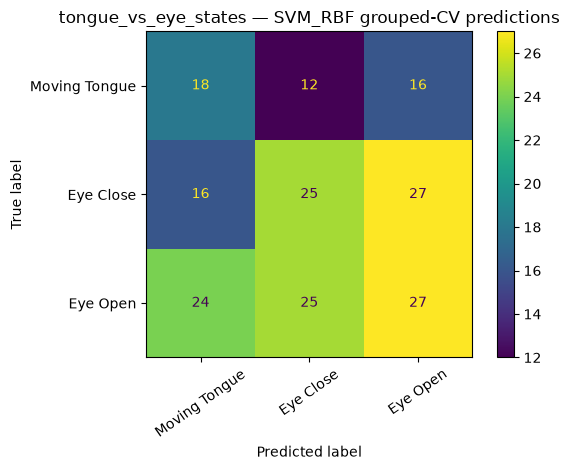

,precision,recall,f1-score,support
Moving Tongue,0.310,0.391,0.346,46.000
Eye Close,0.403,0.368,0.385,68.000
Eye Open,0.386,0.355,0.370,76.000
accuracy,0.368,0.368,0.368,0.368
macro avg,0.366,0.371,0.367,190.000
weighted avg,0.374,0.368,0.369,190.000


In [17]:

# Confusion matrix + class report for the strongest mean balanced-accuracy
# feature model in each task. This is model selection for inspection only;
# do not claim an unbiased final estimate after choosing the best model on the same CV.
for task_name, obj in ALL_RESULTS.items():
    summary = obj["summary"]
    if len(summary) == 0:
        continue

    best_name = summary.sort_values("balanced_accuracy_mean", ascending=False).iloc[0]["model"]
    det = obj["details"][best_name]

    print("\n", task_name, "| inspected model:", best_name)
    ConfusionMatrixDisplay(det["cm"], display_labels=det["labels"]).plot(
        xticks_rotation=35, values_format="d"
    )
    plt.title(f"{task_name} — {best_name} grouped-CV predictions")
    plt.tight_layout()
    plt.show()

    report_df = pd.DataFrame(det["report"]).T
    display(report_df.round(3))



## 12. CSP + LDA for left-vs-right motor classification

Common Spatial Patterns (CSP) is especially appropriate for binary motor EEG when the two classes have different spatial variance patterns.

This implementation:

- receives the **2-second channel × sample epochs**;
- estimates CSP filters on training folds only;
- uses log-variance CSP features;
- classifies with shrinkage LDA.

It is evaluated separately for:

- left hand vs right hand;
- left leg vs right leg.

CSP can also learn movement/EMG topographies, so interpret it together with artifact metrics and ERD/ERS.



CSP: hand_L_vs_R


,task,fold,balanced_accuracy,macro_f1,test_spans
0,hand_L_vs_R,0,0.285714,0.266667,3
1,hand_L_vs_R,1,0.319231,0.300203,5
2,hand_L_vs_R,2,0.333333,0.258065,5
3,hand_L_vs_R,3,0.634615,0.630542,6
4,hand_L_vs_R,4,0.238095,0.215909,5


Mean:


,mean
balanced_accuracy,0.362
macro_f1,0.334


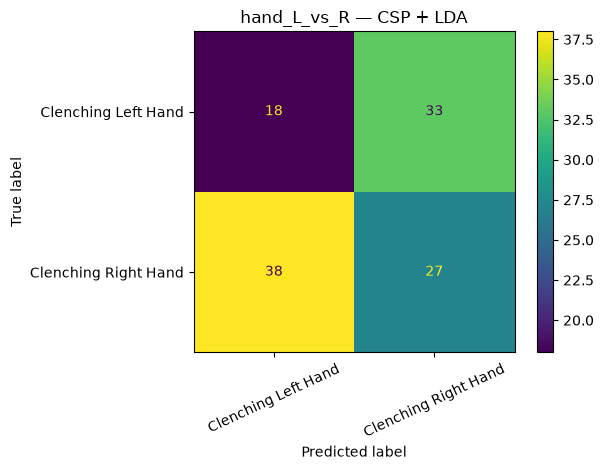


CSP: leg_L_vs_R


,task,fold,balanced_accuracy,macro_f1,test_spans
0,leg_L_vs_R,0,0.609091,0.596154,5
1,leg_L_vs_R,1,0.303571,0.305263,5
2,leg_L_vs_R,2,0.305556,0.293269,5
3,leg_L_vs_R,3,0.227273,0.200000,4
4,leg_L_vs_R,4,0.386364,0.375286,5


Mean:


,mean
balanced_accuracy,0.366
macro_f1,0.354


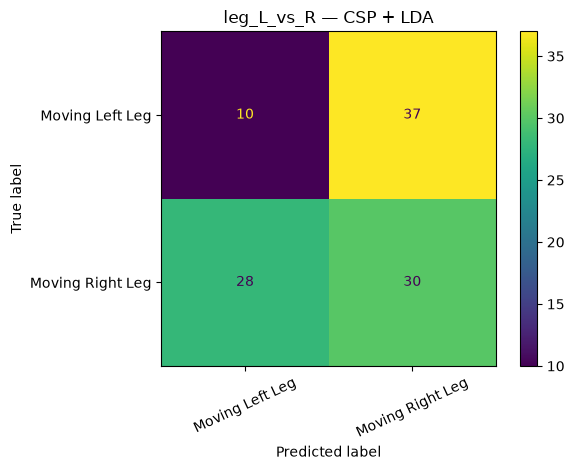

In [18]:

class CSPTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=4, reg=1e-6):
        self.n_components = n_components
        self.reg = reg

    @staticmethod
    def _cov(epoch, reg):
        c = epoch @ epoch.T
        c = c / max(np.trace(c), 1e-20)
        c = c + reg * np.eye(c.shape[0])
        return c

    def fit(self, X, y):
        classes = np.unique(y)
        if len(classes) != 2:
            raise ValueError("CSPTransformer requires exactly two classes")
        self.classes_ = classes

        covs = {}
        for cls in classes:
            cs = [self._cov(ep, self.reg) for ep in X[y == cls]]
            covs[cls] = np.mean(cs, axis=0)

        c0, c1 = covs[classes[0]], covs[classes[1]]
        vals, vecs = eigh(c0, c0 + c1)
        order = np.argsort(vals)
        # Alternate most class-0 and most class-1 discriminative filters.
        pick = []
        left, right = 0, len(order) - 1
        while len(pick) < min(self.n_components, len(order)):
            pick.append(order[left])
            left += 1
            if len(pick) < min(self.n_components, len(order)):
                pick.append(order[right])
                right -= 1
        self.filters_ = vecs[:, pick].T
        return self

    def transform(self, X):
        out = []
        for ep in X:
            z = self.filters_ @ ep
            var = np.var(z, axis=1)
            var = var / max(var.sum(), 1e-20)
            out.append(np.log(np.maximum(var, 1e-20)))
        return np.asarray(out)


def evaluate_csp_task(task_name):
    if task_name not in ("hand_L_vs_R", "leg_L_vs_R"):
        raise ValueError("CSP section is for the binary motor tasks")

    labels = TASKS[task_name]
    mask = np.isin(EPOCHS.y, labels)
    X = EPOCHS.X[mask]
    y = EPOCHS.y[mask]
    groups = EPOCHS.groups[mask]

    if len(np.unique(y)) != 2:
        raise ValueError(f"{task_name}: both classes are required")

    cv, n_splits = choose_group_cv(y, groups)
    n_comp = min(4, X.shape[1])
    pipe = Pipeline([
        ("csp", CSPTransformer(n_components=n_comp, reg=1e-6)),
        ("scale", StandardScaler()),
        ("model", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])

    rows, yt, yp = [], [], []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups)):
        fit = clone(pipe).fit(X[tr], y[tr])
        pred = fit.predict(X[te])
        rows.append({
            "task": task_name,
            "fold": fold,
            "balanced_accuracy": balanced_accuracy_score(y[te], pred),
            "macro_f1": f1_score(y[te], pred, average="macro"),
            "test_spans": len(np.unique(groups[te])),
        })
        yt.extend(y[te])
        yp.extend(pred)

    folds = pd.DataFrame(rows)
    cm = confusion_matrix(yt, yp, labels=labels)
    return folds, cm, labels


CSP_RESULTS = {}
for task_name in ("hand_L_vs_R", "leg_L_vs_R"):
    print("\nCSP:", task_name)
    try:
        folds, cm, labels = evaluate_csp_task(task_name)
        CSP_RESULTS[task_name] = folds
        display(folds)
        print("Mean:")
        display(folds[["balanced_accuracy", "macro_f1"]].mean().to_frame("mean").round(3))
        ConfusionMatrixDisplay(cm, display_labels=labels).plot(
            xticks_rotation=25, values_format="d"
        )
        plt.title(f"{task_name} — CSP + LDA")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Skipped:", e)



## 13. Permutation-label sanity check

A serious EEG pipeline should verify that its grouped CV does not retain accidental leakage.

This section shuffles labels at the **span level**, not independently per overlapping epoch. If performance remains far above chance after span-label permutation, inspect the pipeline for leakage or session/order confounds.


In [19]:

def span_level_permutation_score(task_name, n_permutations=25):
    d, X, y, groups, feature_cols = task_frame(task_name)
    cv, _ = choose_group_cv(y, groups)
    model = make_models(X.shape[1])["LDA"]
    rng = np.random.default_rng(RANDOM_STATE)

    # Observed
    obs = []
    for tr, te in cv.split(X, y, groups):
        pred = clone(model).fit(X[tr], y[tr]).predict(X[te])
        obs.append(balanced_accuracy_score(y[te], pred))
    observed = float(np.mean(obs))

    # One label per span, then shuffle those span labels.
    span_df = pd.DataFrame({"group": groups, "label": y}).drop_duplicates("group")
    group_to_indices = {g: np.where(groups == g)[0] for g in np.unique(groups)}

    null = []
    for _ in range(n_permutations):
        shuffled_labels = span_df["label"].to_numpy().copy()
        rng.shuffle(shuffled_labels)
        group_to_label = dict(zip(span_df["group"], shuffled_labels))
        y_perm = np.array([group_to_label[g] for g in groups])

        fold_scores = []
        # Split using original y to maintain comparable grouped folds.
        for tr, te in cv.split(X, y, groups):
            fit = clone(model).fit(X[tr], y_perm[tr])
            pred = fit.predict(X[te])
            fold_scores.append(balanced_accuracy_score(y_perm[te], pred))
        null.append(np.mean(fold_scores))

    return observed, np.array(null)


PERMUTATION_ROWS = []
for task_name in TASKS:
    try:
        observed, null = span_level_permutation_score(task_name, n_permutations=25)
        p = (1 + np.sum(null >= observed)) / (1 + len(null))
        PERMUTATION_ROWS.append({
            "task": task_name,
            "observed_balanced_accuracy": observed,
            "null_mean": null.mean(),
            "null_std": null.std(ddof=1),
            "permutation_p_approx": p,
            "chance_balanced_accuracy": 1 / len(TASKS[task_name]),
        })
    except Exception as e:
        print(task_name, "permutation skipped:", e)

PERMUTATION_TABLE = pd.DataFrame(PERMUTATION_ROWS)
display(PERMUTATION_TABLE.round(3))


C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


...

C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\sobha\AppData\Local\Temp\nb7venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,task,observed_balanced_accuracy,null_mean,null_std,permutation_p_approx,chance_balanced_accuracy
0,all_7,0.108,0.140,0.036,0.808,0.143
1,hand_L_vs_R,0.442,0.511,0.106,0.769,0.500
2,leg_L_vs_R,0.490,0.502,0.124,0.577,0.500
3,tongue_vs_eye_states,0.332,0.306,0.071,0.462,0.333



## 14. Artifact sensitivity check

For physical movement data, a classifier may exploit EMG or electrode motion.

A practical warning sign is:

- unusually high high-frequency power / peak-to-peak amplitude during one class;
- a high percentage of filtered 2-second epochs exceeding **±100 µV**;
- very high accuracy that collapses after contaminated windows are removed;
- strong class separation in frontal/temporal gamma but weak central mu/beta ERD/ERS.

The next tables compare artifact metrics by class. The **±100 µV metric is a literature-comparable screening statistic**, whereas the notebook's separate `keep` rule controls actual epoch retention.


In [20]:

if len(EPOCHS.artifact_info):
    artifact_by_class = EPOCHS.artifact_info.groupby("label").agg(
        candidate_windows=("keep", "size"),
        rejection_rate=("keep", lambda x: 1 - x.mean()),
        median_max_abs_uv=("max_abs_uv", "median"),
        median_max_ptp_uv=("max_ptp_uv", "median"),
        median_max_step_uv=("max_step_uv", "median"),
        mi_percent_epochs_over_100uv=(
            "mi_epoch_exceeds_100uv", lambda x: 100.0 * x.mean()
        ),
    ).reindex(CLASS_ORDER)
    display(artifact_by_class.round(3))

if len(FEATURES):
    hf_cols = [c for c in FEATURES.columns if c.endswith("__gamma_rel")]
    rms_cols = [c for c in FEATURES.columns if c.endswith("__rms")]
    if hf_cols and rms_cols:
        tmp = FEATURES[["label"]].copy()
        tmp["mean_gamma_rel"] = FEATURES[hf_cols].mean(axis=1)
        tmp["mean_rms"] = FEATURES[rms_cols].mean(axis=1)
        display(
            tmp.groupby("label")[["mean_gamma_rel", "mean_rms"]]
            .median().reindex(CLASS_ORDER).round(4)
        )


,candidate_windows,rejection_rate,median_max_abs_uv,median_max_ptp_uv,median_max_step_uv,mi_percent_epochs_over_100uv
label,,,,,,
Clenching Left Hand,51,0.0,33.139,59.949,7.281,3.922
Clenching Right Hand,65,0.0,35.500,59.626,7.560,0.000
Moving Left Leg,47,0.0,35.500,62.297,7.261,2.128
Moving Right Leg,58,0.0,35.912,61.866,7.862,3.448
Moving Tongue,46,0.0,33.440,60.088,6.910,0.000
Eye Open,76,0.0,35.977,64.804,7.323,3.947
Eye Close,68,0.0,33.750,58.375,7.736,0.000


,mean_gamma_rel,mean_rms
label,,
Clenching Left Hand,0.0094,7.1292
Clenching Right Hand,0.0105,7.4920
Moving Left Leg,0.0100,7.0054
Moving Right Leg,0.0092,7.5412
Moving Tongue,0.0099,7.3566
Eye Open,0.0096,7.5695
Eye Close,0.0098,7.3647



## 15. Final model fitting and export

After you have chosen a model based on a **predefined** analysis plan, this cell fits that model on all currently available cleaned windows and saves it for later inference.

For deployment, reproduce the exact same:

- channel order;
- sampling rate;
- 60 Hz notch;
- 1–45 Hz filter;
- CAR choice;
- 2-second window;
- feature extraction.

A saved model is not a validated real-world BCI until it has been tested on **new sessions and preferably new participants** that were not used during model development.


In [21]:

# Choose a fixed model family for export. LDA is a strong small-sample baseline.
EXPORT_MODEL_NAME = "LDA"

EXPORTED = []
for task_name in TASKS:
    try:
        d, X, y, groups, feature_cols = task_frame(task_name)
        if len(np.unique(y)) != len(TASKS[task_name]):
            continue

        model = make_models(X.shape[1])[EXPORT_MODEL_NAME]
        model.fit(X, y)

        bundle = {
            "pipeline": model,
            "task": task_name,
            "classes": TASKS[task_name],
            "feature_columns": feature_cols,
            "channel_names": EPOCHS.names,
            "sf_hz": EPOCHS.sf,
            "window_seconds": WINDOW_SECONDS,
            "step_seconds_training": STEP_SECONDS,
            "filter": {
                "notch_hz": MAINS_HZ,
                "bandpass_hz": [L_FREQ, H_FREQ],
                "common_average_reference": APPLY_CAR,
            },
            "artifact_thresholds": {
                "max_abs_uv": MAX_ABS_UV,
                "max_ptp_uv": MAX_PTP_UV,
                "max_step_uv": MAX_STEP_UV,
                "flat_std_uv": FLAT_STD_UV,
                "max_bad_channel_fraction": MAX_BAD_CHANNEL_FRACTION,
                "mi_comparison_abs_threshold_uv": MI_ABS_THRESHOLD_UV,
            },
            "note": "Evaluation must be reported separately from this fit-on-all deployment model.",
        }

        path = MODEL_DIR / f"{task_name}_{EXPORT_MODEL_NAME}_2s.joblib"
        joblib.dump(bundle, path)

        meta_path = path.with_suffix(".json")
        meta = {k: v for k, v in bundle.items() if k != "pipeline"}
        meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")

        EXPORTED.append(str(path))
        print("Saved:", path)
    except Exception as e:
        print(task_name, "export skipped:", e)


Saved: ..\Session_Classification\_models_7class_2s\all_7_LDA_2s.joblib
Saved: ..\Session_Classification\_models_7class_2s\hand_L_vs_R_LDA_2s.joblib
Saved: ..\Session_Classification\_models_7class_2s\leg_L_vs_R_LDA_2s.joblib
Saved: ..\Session_Classification\_models_7class_2s\tongue_vs_eye_states_LDA_2s.joblib



## 16. Export analysis tables


In [22]:

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if len(INVENTORY):
    INVENTORY.to_csv(RESULTS_DIR / "recording_inventory.csv", index=False)
if len(SPANS):
    SPANS.to_csv(RESULTS_DIR / "span_inventory.csv", index=False)
if len(QUALITY_RAW):
    QUALITY_RAW.to_csv(RESULTS_DIR / "signal_quality_raw.csv", index=False)
if len(QUALITY_PROCESSED):
    QUALITY_PROCESSED.to_csv(RESULTS_DIR / "signal_quality_processed.csv", index=False)
if len(QUALITY_COMPARISON):
    QUALITY_COMPARISON.to_csv(RESULTS_DIR / "signal_quality_before_after_comparison.csv", index=False)
if len(QUALITY):
    QUALITY.to_csv(RESULTS_DIR / "signal_quality_all_stages.csv", index=False)
if len(EPOCHS.artifact_info):
    EPOCHS.artifact_info.to_csv(RESULTS_DIR / "epoch_artifact_qc.csv", index=False)
if "MI_EPOCH_QC" in globals() and len(MI_EPOCH_QC):
    MI_EPOCH_QC.to_csv(RESULTS_DIR / "mi_100uv_epoch_qc.csv", index=False)
if "MI_EPOCH_SUMMARY_BY_CLASS" in globals() and len(MI_EPOCH_SUMMARY_BY_CLASS):
    MI_EPOCH_SUMMARY_BY_CLASS.to_csv(
        RESULTS_DIR / "mi_100uv_summary_by_class.csv"
    )
if "MI_EPOCH_SUMMARY_BY_SESSION" in globals() and len(MI_EPOCH_SUMMARY_BY_SESSION):
    MI_EPOCH_SUMMARY_BY_SESSION.to_csv(
        RESULTS_DIR / "mi_100uv_summary_by_session.csv"
    )
if "MI_CHANNEL_QC" in globals() and len(MI_CHANNEL_QC):
    MI_CHANNEL_QC.to_csv(RESULTS_DIR / "mi_100uv_channel_epoch_qc.csv", index=False)
if "MI_CHANNEL_SUMMARY" in globals() and len(MI_CHANNEL_SUMMARY):
    MI_CHANNEL_SUMMARY.to_csv(
        RESULTS_DIR / "mi_100uv_summary_by_channel.csv"
    )
if len(FEATURES):
    FEATURES.to_csv(RESULTS_DIR / "epoch_features_2s.csv", index=False)
if len(ERDS_CONDITION):
    ERDS_CONDITION.to_csv(RESULTS_DIR / "erds_condition_reference.csv", index=False)
if len(ERDS_CUE):
    ERDS_CUE.to_csv(RESULTS_DIR / "erds_cue_locked.csv", index=False)
if len(PERMUTATION_TABLE):
    PERMUTATION_TABLE.to_csv(RESULTS_DIR / "permutation_sanity_check.csv", index=False)

model_summary_parts = []
for task_name, obj in ALL_RESULTS.items():
    s = obj["summary"].copy()
    model_summary_parts.append(s)
if model_summary_parts:
    MODEL_SUMMARY = pd.concat(model_summary_parts, ignore_index=True)
    MODEL_SUMMARY.to_csv(RESULTS_DIR / "classification_grouped_cv_summary.csv", index=False)
    display(MODEL_SUMMARY.round(3))

print("Analysis outputs:", RESULTS_DIR)
print("Models:", MODEL_DIR)


,task,model,cv_folds,epochs,spans,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
0,all_7,LDA,5,411,83,0.108,0.045,0.100,0.042
1,all_7,LogisticRegression,5,411,83,0.113,0.046,0.110,0.042
2,all_7,SVM_RBF,5,411,83,0.094,0.054,0.092,0.050
3,all_7,RandomForest,5,411,83,0.112,0.050,0.099,0.042
4,hand_L_vs_R,LDA,5,116,24,0.442,0.038,0.428,0.040
5,hand_L_vs_R,LogisticRegression,5,116,24,0.498,0.076,0.483,0.084
6,hand_L_vs_R,SVM_RBF,5,116,24,0.330,0.152,0.311,0.150
7,hand_L_vs_R,RandomForest,5,116,24,0.403,0.176,0.387,0.180
8,leg_L_vs_R,LDA,5,105,24,0.490,0.101,0.482,0.105
9,leg_L_vs_R,LogisticRegression,5,105,24,0.480,0.074,0.472,0.079


Analysis outputs: ..\Session_Classification\_analysis_7class_2s
Models: ..\Session_Classification\_models_7class_2s



## 17. Interpretation checklist

Before reporting a classifier result, check all of these:

1. **Independent spans:** report the number of labeled spans per class, not just the number of overlapping 2-second windows.
2. **No window leakage:** windows from a single span must remain in one CV fold.
3. **Session generalization:** if possible, repeat evaluation by leaving an entire session out.
4. **Participant generalization:** with multiple participants, the strongest test is leave-participant-out evaluation.
5. **Raw signal quality:** report raw robust PTP, RMS, line noise, drift, extreme-amplitude burden, and channel-level flags.
6. **Processed signal quality:** separately report the same QC panel after notch + band-pass + CAR.
7. **MI-style amplitude QC:** report the percentage of filtered 2-second epochs in which any channel exceeds ±100 µV, overall and by class/channel.
8. **Do not hide acquisition problems with filtering:** a clean processed signal does not prove that the raw acquisition was clean.
9. **Artifact validity:** physical movement can produce EMG/electrode motion. Do not interpret high accuracy as cortical decoding without artifact checks.
10. **Motor physiology:** left/right hand interpretation should be supported by plausible C3/C4/Cz mu/beta patterns, not only by a black-box accuracy number.
11. **Eye-open/eye-close:** occipital alpha changes are expected to be strong and can dominate the seven-class problem.
12. **Tongue:** tongue movement is particularly vulnerable to cranial muscle artifact; inspect high-frequency and frontal/temporal contamination carefully.
13. **ERD/ERS:** cue-locked baseline is preferable to a separate-condition baseline when onset timing is reliable.
14. **Chance levels:** 7-class chance is about 14.3%, binary chance is 50%, and 3-class chance is about 33.3%, but balanced accuracy and permutation testing are better than comparing only with nominal chance.
15. **External validation:** a final BCI model should be tested on unseen recordings acquired on a later session, and ideally on unseen participants.

### Recommended minimum reporting table

For each of the four classification tasks report:

- participants;
- sessions;
- independent spans per class;
- kept/rejected 2-second windows;
- filter/reference settings;
- **RAW QC summary**;
- **PROCESSED QC summary**;
- raw-to-processed change in robust PTP, RMS and 60-Hz power;
- **percentage of filtered 2-second epochs exceeding ±100 µV**, overall and by class/channel;
- model;
- grouped CV strategy;
- balanced accuracy mean ± SD;
- macro-F1 mean ± SD;
- confusion matrix;
- permutation sanity result;
- ERD/ERS observations for relevant channels/bands.

### QC files exported by this notebook

- `signal_quality_raw.csv`
- `signal_quality_processed.csv`
- `signal_quality_before_after_comparison.csv`
- `signal_quality_all_stages.csv`
- `mi_100uv_epoch_qc.csv`
- `mi_100uv_summary_by_class.csv`
- `mi_100uv_summary_by_session.csv`
- `mi_100uv_channel_epoch_qc.csv`
- `mi_100uv_summary_by_channel.csv`

These files are intended to make the signal-quality analysis auditable and suitable for research reporting.
